# Projekt końcowy — analiza danych i predykcja cen domów

Celem projektu jest analiza danych dotyczących sprzedaży domów oraz zbudowanie modelu predykcyjnego przewidującego `SalePrice`.

Notebook zawiera:
- wczytanie danych treningowych i testowych,
- eksploracyjną analizę danych,
- analizę braków danych,
- wizualizacje zależności między cechami a ceną,
- kodowanie zmiennych kategorycznych,
- uzupełnianie braków danych,
- podstawowe metody statystyczne,
- modele regresyjne i wygenerowanie pliku `submission.csv`.

## 1. Import bibliotek

W tej części importujemy biblioteki potrzebne do analizy danych, wizualizacji oraz modelowania regresyjnego.

In [660]:
# Podstawowe biblioteki do pracy z danymi
import pandas as pd
import numpy as np
import math

# Wizualizacja danych
import seaborn as sns
import matplotlib.pyplot as plt

# Metody statystyczne
from scipy.stats import pearsonr, spearmanr, f_oneway

# Modele i narzędzia machine learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ustawienia wykresów
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Wczytanie danych

W projekcie wykorzystuję pliki:
- `train.csv` — dane treningowe z kolumną docelową `SalePrice`,
- `test.csv` — dane testowe bez ceny, dla których na końcu generowana jest predykcja.

In [661]:
# Wczytanie danych z plików CSV znajdujących się w tym samym folderze co notebook
df = pd.read_csv("train.csv")
testowe = pd.read_csv("test.csv")

# Podgląd pierwszych wierszy danych treningowych
display(df.head())

print("Rozmiar danych treningowych:", df.shape)
print("Rozmiar danych testowych:", testowe.shape)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Rozmiar danych treningowych: (1460, 81)
Rozmiar danych testowych: (1459, 80)


## 3. Pytania badawcze

W analizie odpowiadam na następujące pytania:

1. Które zmienne numeryczne są najmocniej skorelowane z ceną domu?
2. Jak oczyścić i przekształcić dane, aby można było wykorzystać je w modelu predykcyjnym??
3. Które dzielnice (`Neighborhood`) mają najwyższe średnie ceny domów?

## 4. Podstawowa eksploracja danych

Sprawdzamy typy kolumn, statystyki opisowe i podstawowe informacje o zbiorze.

In [662]:
# Informacje o typach danych i liczbie braków w kolumnach
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [663]:
# Statystyki opisowe dla zmiennych numerycznych
display(df.describe())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [664]:
# Lista kolumn tekstowych/kategorycznych
object_columns = df.select_dtypes(include='object').columns

print("Liczba kolumn kategorycznych:", len(object_columns))
display(object_columns)

Liczba kolumn kategorycznych: 43


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

## 5. ANALIZA braków danych

Najpierw sprawdzam, które kolumny posiadają braki danych. Jest to ważne, ponieważ modele machine learning zwykle nie przyjmują wartości `NaN`.

In [665]:
# Liczba braków danych w każdej kolumnie
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Kolumny z brakami danych w zbiorze treningowym:")
display(missing_values)

Kolumny z brakami danych w zbiorze treningowym:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

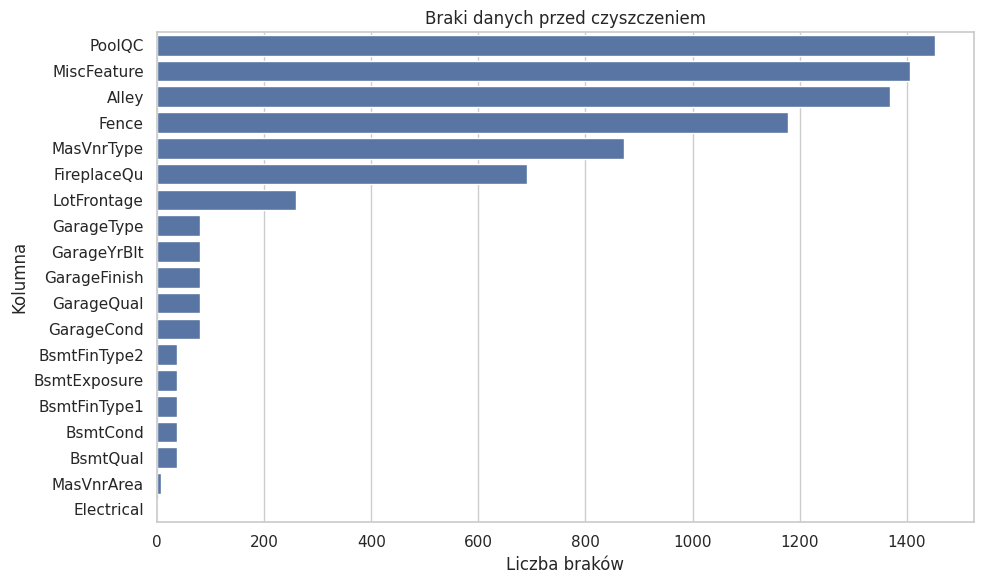

In [666]:
# Wykres liczby braków danych w kolumnach
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.values, y=missing_values.index)

plt.title("Braki danych przed czyszczeniem")
plt.xlabel("Liczba braków")
plt.ylabel("Kolumna")
plt.tight_layout()
plt.show()

**Wniosek:** kolumny z dużą liczbą braków wymagają specjalnego traktowania. W dalszej części część braków zostanie zastąpiona kategorią `None`, a część wartościami liczbowymi, np. `0` lub medianą.

## 6. Analiza zmiennej docelowej `SalePrice`

`SalePrice` jest zmienną, którą chcemy przewidywać. Najpierw sprawdzam jej rozkład.

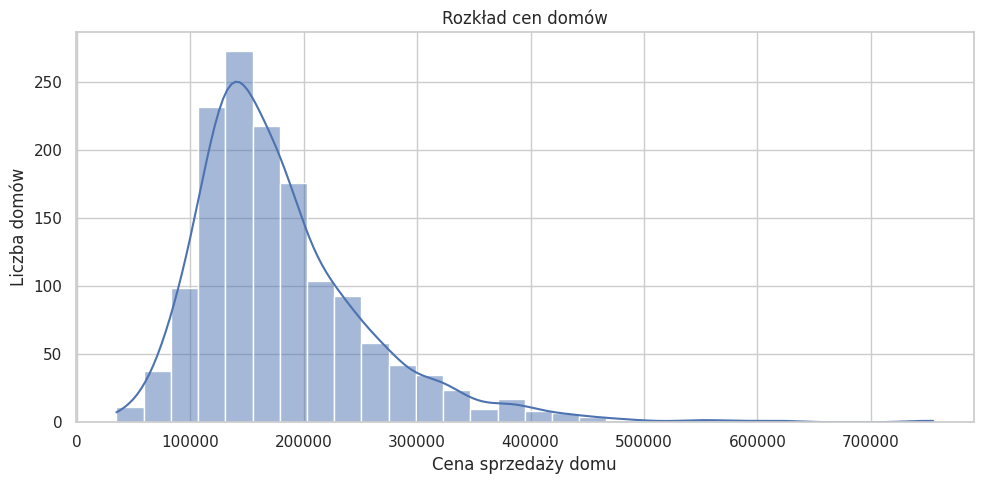

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [667]:
# Rozkład ceny sprzedaży domów
plt.figure(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, bins=30)

plt.title("Rozkład cen domów")
plt.xlabel("Cena sprzedaży domu")
plt.ylabel("Liczba domów")
plt.tight_layout()
plt.show()

display(df['SalePrice'].describe())

## 7. Utworzenie kopii roboczych danych

Tworzę kopie `df1` i `testowe1`, aby nie nadpisywać oryginalnych danych. Na tych kopiach będą wykonywane czyszczenie, kodowanie i przygotowanie pod modele.

In [668]:
# Kopie robocze danych
# df1 — dane treningowe po czyszczeniu
# testowe1 — dane testowe po czyszczeniu

df1 = df.copy()
testowe1 = testowe.copy()

## 8. Identyfikacja zmiennych porządkowych

Część kolumn ma wartości tekstowe typu `Po`, `Fa`, `TA`, `Gd`, `Ex`. Są to zmienne porządkowe, bo oznaczają poziomy jakości od najgorszego do najlepszego.

Przykład kolejności:

`None < Po < Fa < TA < Gd < Ex`

In [669]:
# Szukamy kolumn tekstowych, które zawierają poziomy jakości
values_to_find = {'Po', 'Fa', 'TA', 'Gd', 'Ex'}

obj_cols = df.select_dtypes(include='object').columns

cols_with_quality_values = [col for col in obj_cols if df[col].isin(values_to_find).any()]

print("Kolumny z wartościami jakościowymi:")
display(cols_with_quality_values)

Kolumny z wartościami jakościowymi:


['ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'HeatingQC',
 'KitchenQual',
 'FireplaceQu',
 'GarageQual',
 'GarageCond',
 'PoolQC']

In [670]:
# Podgląd unikalnych wartości dla najważniejszych kolumn jakościowych
quality_preview_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC',
    'GarageFinish', 'BsmtFinType1', 'BsmtFinType2'
]

for col in quality_preview_cols:
    print(f"{col}:")
    display(df[col].unique())

ExterQual:


array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

ExterCond:


array(['TA', 'Gd', 'Fa', 'Po', 'Ex'], dtype=object)

BsmtQual:


...

array(['RFn', 'Unf', 'Fin', nan], dtype=object)

BsmtFinType1:


array(['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ'], dtype=object)

BsmtFinType2:


array(['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

In [671]:
display(df1['BsmtFinType2'].unique())
display(df1['GarageFinish'].unique())

array(['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ'], dtype=object)

array(['RFn', 'Unf', 'Fin', nan], dtype=object)

## 9. Kodowanie zmiennych porządkowych

Zmieniam wartości tekstowe na liczby, ponieważ modele regresyjne wymagają danych numerycznych.

Przykład:
- `Po` = 1,
- `Fa` = 2,
- `TA` = 3,
- `Gd` = 4,
- `Ex` = 5.

Braki danych w tych kolumnach traktuję jako `None`, czyli brak danej cechy.

In [672]:
# Mapowanie ogólnych ocen jakości
qual_map = {'None': 0,'Po': 1,'Fa': 2,'TA': 3,'Gd': 4,'Ex': 5}

# Mapowanie piwnicy
exposure_map = {'None': 0,'No': 1,'Mn': 2,'Av': 3,'Gd': 4}

# Kolumny z ocenami jakości/warunków
qual_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC']

# Mapowanie wykończenia garażu
# None — brak garażu, Unf — unfinished, RFn — rough finished, Fin — finished
garage_finish_map = {'None': 0,'Unf': 1,'RFn': 2,'Fin': 3}

# Mapowanie typu wykończenia piwnicy
bsmt_fin_map = {'None': 0,'Unf': 1,'LwQ': 2,'Rec': 3,'BLQ': 4,'ALQ': 5,'GLQ': 6}

In [673]:
# Kodowanie kolumn porządkowych w danych treningowych
for col in qual_cols:
    df1[col] = df1[col].fillna('None').map(qual_map)

df1['BsmtExposure'] = df1['BsmtExposure'].fillna('None').map(exposure_map)
df1['GarageFinish'] = df1['GarageFinish'].fillna('None').map(garage_finish_map)
df1['BsmtFinType2'] = df1['BsmtFinType2'].fillna('None').map(bsmt_fin_map)
df1['BsmtFinType1'] = df1['BsmtFinType1'].fillna('None').map(bsmt_fin_map)

In [674]:
# To samo kodowanie wykonujemy dla danych testowych,
# aby train i test były przygotowane w spójny sposób.
for col in qual_cols:
    testowe1[col] = testowe1[col].fillna('None').map(qual_map)

testowe1['BsmtExposure'] = testowe1['BsmtExposure'].fillna('None').map(exposure_map)
testowe1['GarageFinish'] = testowe1['GarageFinish'].fillna('None').map(garage_finish_map)
testowe1['BsmtFinType2'] = testowe1['BsmtFinType2'].fillna('None').map(bsmt_fin_map)
testowe1['BsmtFinType1'] = testowe1['BsmtFinType1'].fillna('None').map(bsmt_fin_map)

## 10. Wizualizacja: jakość cech a cena domu

Poniższe wykresy pudełkowe pokazują, jak poziom jakości wybranych cech wiąże się z ceną sprzedaży domu.

Jeśli mediana ceny rośnie wraz z poziomem jakości, oznacza to, że dana cecha może mieć wpływ na cenę.

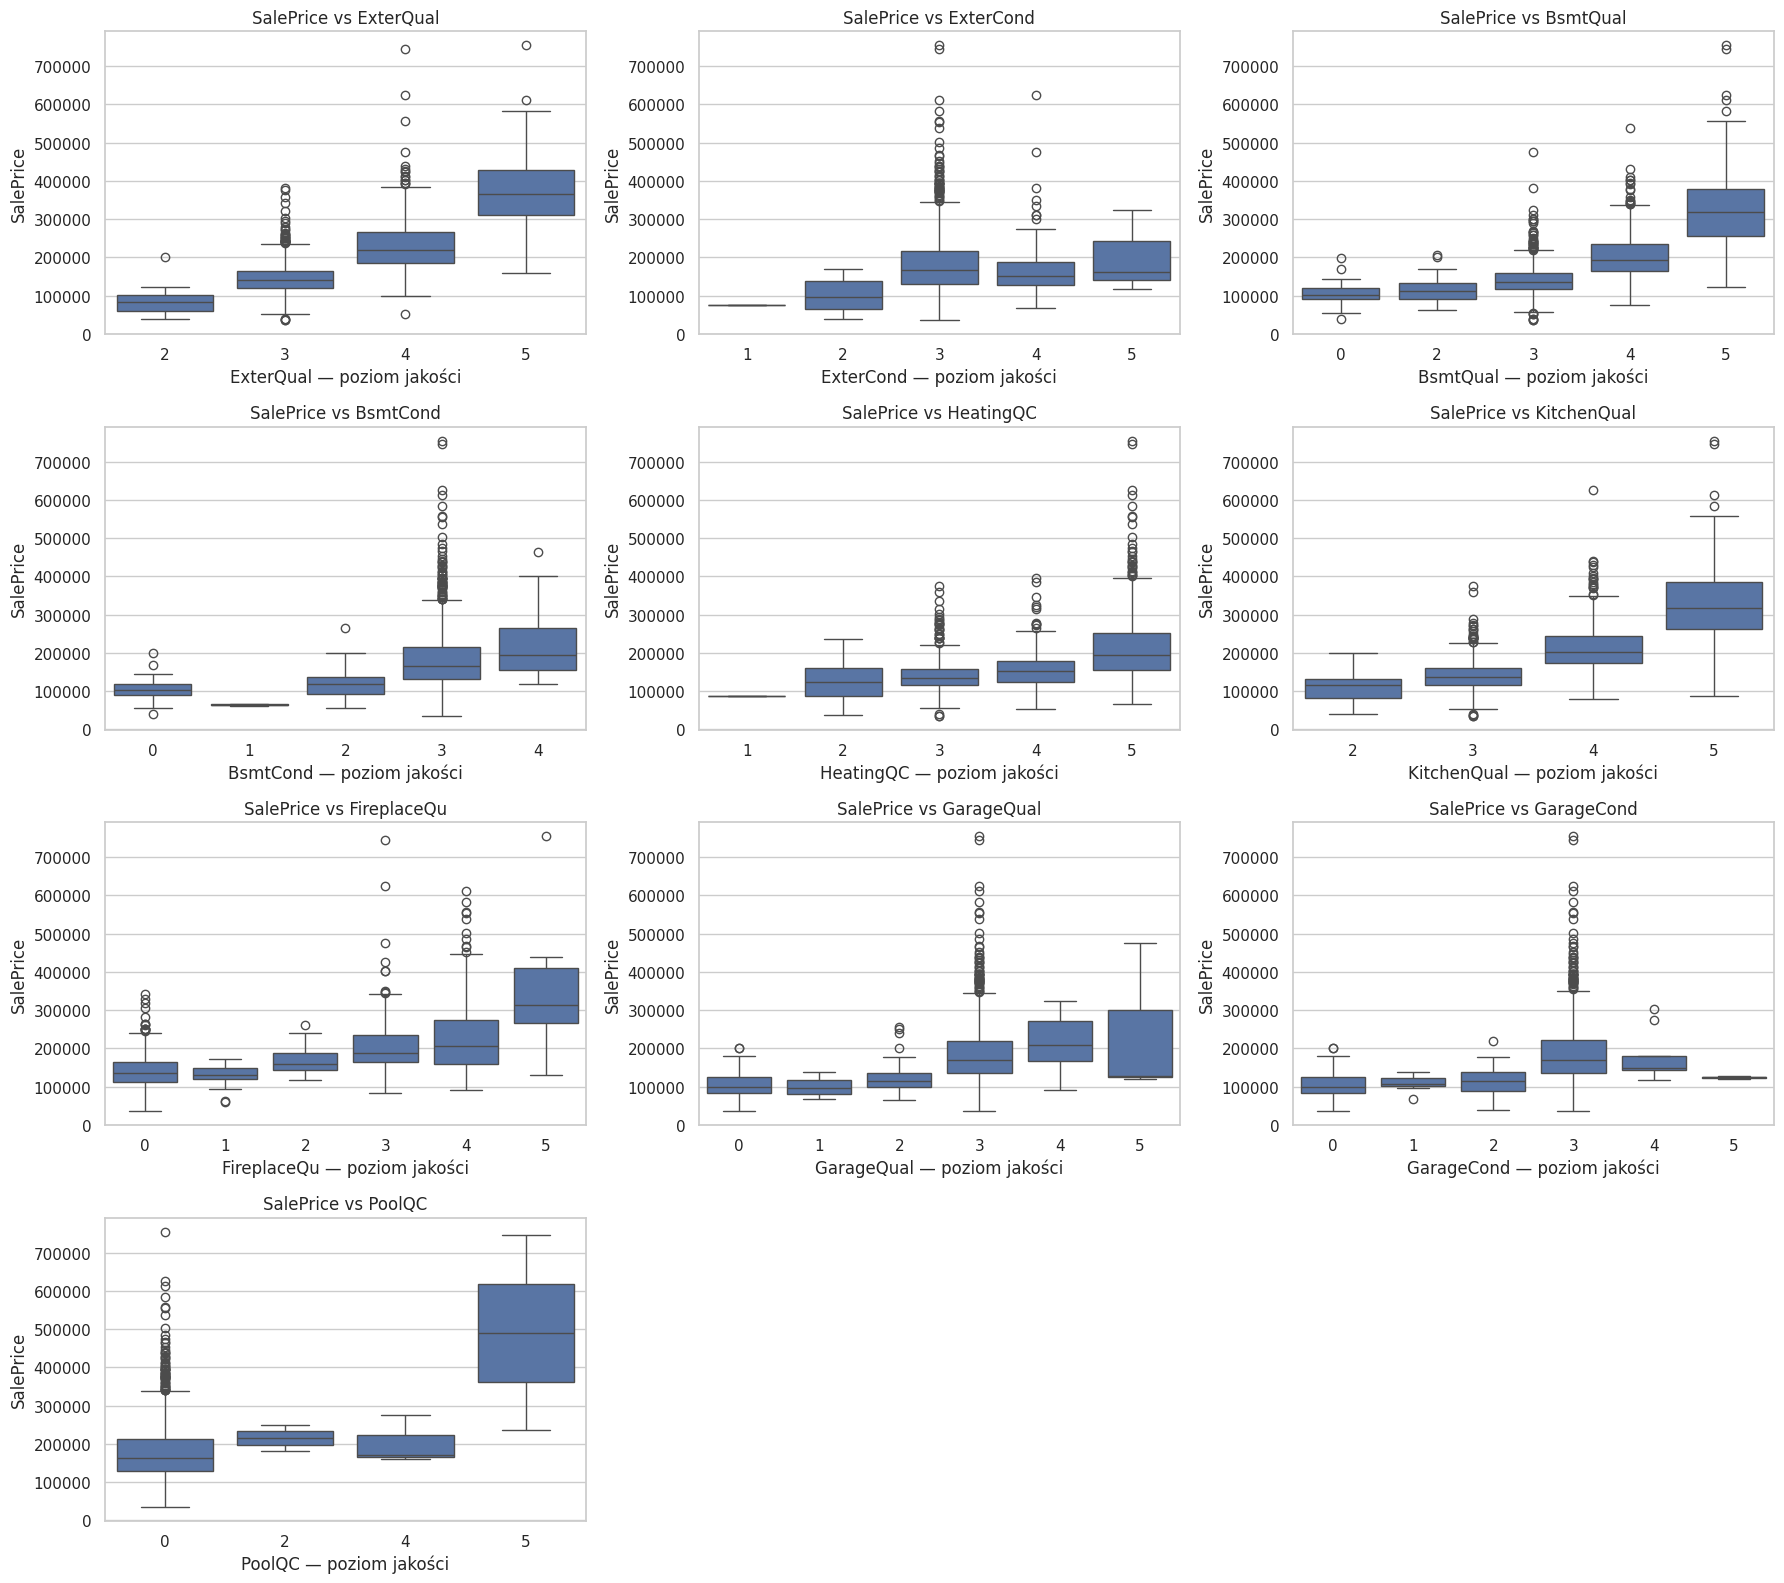

In [675]:
# Boxploty dla cech jakościowych po zakodowaniu na liczby
ncols = 3
nrows = math.ceil(len(qual_cols) / ncols)                           #10/3 i zaokraglenie w gore czyli 4

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))     #4/3
axes = axes.flatten()                                               # [axes[0,0], axes[0,1], axes[0,2]] ... ->   axes[0], axes[1], axes[2],

for i, col in enumerate(qual_cols):
    sns.boxplot(data=df1,x=col,y='SalePrice',ax=axes[i])
    
    axes[i].set_title(f'SalePrice vs {col}')
    axes[i].set_xlabel(f'{col} — poziom jakości')
    axes[i].set_ylabel('SalePrice')

# Usunięcie pustych pól na siatce wykresów
for j in range(i + 1, len(axes)):                                   #9 do 12
    axes[j].remove()

plt.tight_layout()                                                  #poprawia rozmieszczenie wykresów

## 11. Kodowanie wybranych zmiennych nominalnych

Część zmiennych nie ma naturalnej kolejności, np. `GarageType` lub `Electrical`. Takie kolumny koduję metodą `get_dummies`, czyli one-hot encoding.

In [676]:
# Podgląd wybranych zmiennych nominalnych przed kodowaniem
nominal_preview_cols = ['MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'GarageType', 'Electrical']

for col in nominal_preview_cols:
    print(f"{col}:")
    display(df1[col].unique())

MiscFeature:


array([nan, 'Shed', 'Gar2', 'Othr', 'TenC'], dtype=object)

Alley:


array([nan, 'Grvl', 'Pave'], dtype=object)

Fence:


...

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

GarageType:


array(['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types'],
      dtype=object)

Electrical:


array(['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan], dtype=object)

In [677]:
# Kolumny nominalne kodowane przez one-hot encoding
cols_dummy = ['MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'GarageType', 'Electrical']

# Braki w tych kolumnach oznaczają najczęściej brak danej cechy, dlatego zastępuję je kategorią None.
for col in cols_dummy:
    df1[col] = df1[col].fillna('None')

df1 = pd.get_dummies(df1, columns=cols_dummy, drop_first=True)

In [678]:
# To samo kodowanie nominalne dla danych testowych
for col in cols_dummy:
    testowe1[col] = testowe1[col].fillna('None')

testowe1 = pd.get_dummies(testowe1, columns=cols_dummy, drop_first=True)

## 12. Analiza `LotFrontage`

`LotFrontage` oznacza szerokość działki od strony ulicy. Sprawdzam, czy większe wartości tej cechy są powiązane ze średnio wyższą ceną domu.

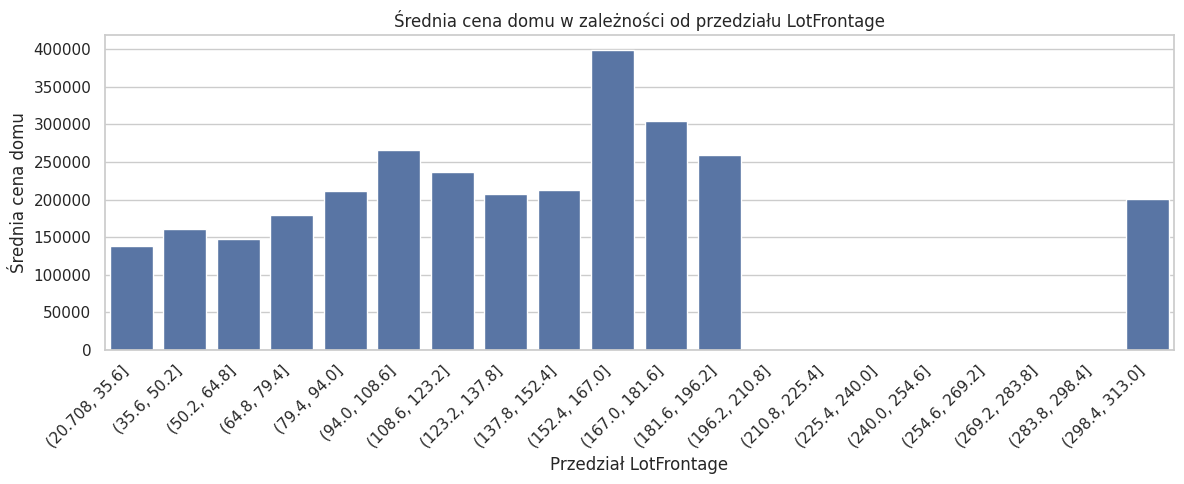

In [679]:
# Następnie dzielimy LotFrontage na przedziały i liczymy średnią cenę w każdym przedziale.

df3 = df.copy()
df3['LotFrontage_bin'] = pd.cut(df3['LotFrontage'], bins=20)

tmp = df3.groupby('LotFrontage_bin', observed=False)['SalePrice'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=tmp, x='LotFrontage_bin', y='SalePrice')

plt.title('Średnia cena domu w zależności od przedziału LotFrontage')
plt.xlabel('Przedział LotFrontage')
plt.ylabel('Średnia cena domu')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [680]:
df3['LotFrontage_bin'].head()

0    (64.8, 79.4]
1    (79.4, 94.0]
2    (64.8, 79.4]
3    (50.2, 64.8]
4    (79.4, 94.0]
Name: LotFrontage_bin, dtype: category
Categories (20, interval[float64, right]): [(20.708, 35.6] < (35.6, 50.2] < (50.2, 64.8] < (64.8, 79.4] ... (254.6, 269.2] < (269.2, 283.8] < (283.8, 298.4] < (298.4, 313.0]]

## 13. Analiza cen według dzielnicy

Lokalizacja jest zwykle jednym z najważniejszych czynników wpływających na cenę nieruchomości. Dlatego sprawdzam średnią cenę domu w każdej dzielnicy.

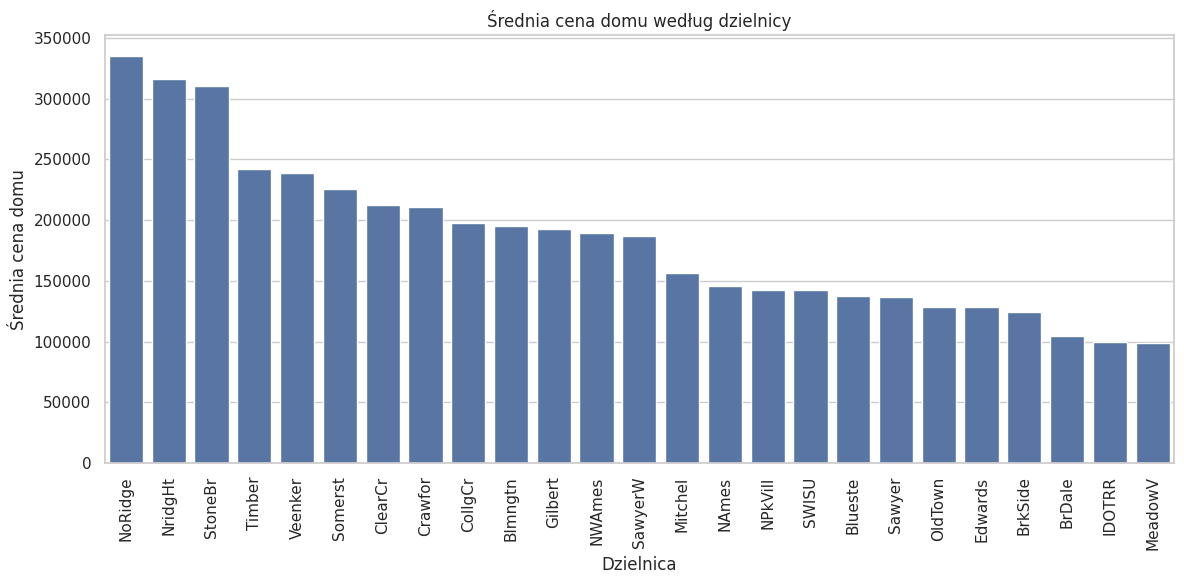

In [681]:
# Średnia cena domu w każdej dzielnicy
neighborhood_price = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=neighborhood_price.index, y=neighborhood_price.values)

plt.title("Średnia cena domu według dzielnicy")
plt.xlabel("Dzielnica")
plt.ylabel("Średnia cena domu")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 14. Uzupełnianie braków danych liczbowych

Dla `LotFrontage` braki uzupełniam medianą w obrębie `Neighborhood`, ponieważ szerokość działki może zależeć od dzielnicy. Jeśli nadal zostaną braki, używam mediany globalnej.

Dla `GarageYrBlt` oraz `MasVnrArea` braki zastępuję wartością `0`, ponieważ często oznaczają brak garażu lub brak powierzchni okładziny.

In [682]:
# Mediana LotFrontage dla każdej dzielnicy na podstawie danych treningowych
lotfront_median_by_neigh = df1.groupby('Neighborhood')['LotFrontage'].median()
lotfront_global_median = df1['LotFrontage'].median()

# Uzupełnianie LotFrontage w danych treningowych
df1['LotFrontage'] = df1['LotFrontage'].fillna(df1['Neighborhood'].map(lotfront_median_by_neigh))   #jezeli mamy dzielnice
df1['LotFrontage'] = df1['LotFrontage'].fillna(lotfront_global_median)                              #gdy lotfrontage jest puste

# Uzupełnianie pozostałych wybranych kolumn liczbowych
df1['GarageYrBlt'] = df1['GarageYrBlt'].fillna(0)
df1['MasVnrArea'] = df1['MasVnrArea'].fillna(0)

In [683]:
# Uzupełnianie LotFrontage w danych testowych na podstawie median z danych treningowych
testowe1['LotFrontage'] = testowe1['LotFrontage'].fillna(testowe1['Neighborhood'].map(lotfront_median_by_neigh))
testowe1['LotFrontage'] = testowe1['LotFrontage'].fillna(lotfront_global_median)

# Uzupełnianie pozostałych wybranych kolumn liczbowych w danych testowych
testowe1['GarageYrBlt'] = testowe1['GarageYrBlt'].fillna(0)
testowe1['MasVnrArea'] = testowe1['MasVnrArea'].fillna(0)

In [684]:
# Sprawdzenie braków danych po wykonaniu części czyszczenia
print("Braki w df1 po czyszczeniu:")
display(df1.isna().sum()[df1.isna().sum() > 0])

print("Braki w testowe1 po czyszczeniu:")
display(testowe1.isna().sum()[testowe1.isna().sum() > 0])

Braki w df1 po czyszczeniu:


Series([], dtype: int64)

Braki w testowe1 po czyszczeniu:


MSZoning        4
Utilities       2
Exterior1st     1
Exterior2nd     1
BsmtFinSF1      1
BsmtFinSF2      1
BsmtUnfSF       1
TotalBsmtSF     1
BsmtFullBath    2
BsmtHalfBath    2
Functional      2
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64

In [685]:
kolumny_z_brakami = testowe1.isna().sum()[testowe1.isna().sum() > 0].index
display(testowe1[kolumny_z_brakami].dtypes)

MSZoning         object
Utilities        object
Exterior1st      object
Exterior2nd      object
BsmtFinSF1      float64
BsmtFinSF2      float64
BsmtUnfSF       float64
TotalBsmtSF     float64
BsmtFullBath    float64
BsmtHalfBath    float64
Functional       object
GarageCars      float64
GarageArea      float64
SaleType         object
dtype: object

In [686]:
cols_to_fill = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'Functional', 'SaleType']

for col in cols_to_fill:
    testowe1[col] = testowe1[col].fillna(df1[col].mode()[0])

### Podsumowanie czyszczenia danych

In [687]:
cleaning_summary = pd.DataFrame({
    'Etap': [
        'Utworzenie kopii danych',
        'Kodowanie zmiennych porządkowych',
        'One-hot encoding zmiennych nominalnych',
        'Uzupełnienie LotFrontage',
        'Uzupełnienie GarageYrBlt i MasVnrArea',
        'Wyrównanie kolumn train/test przed predykcją'
    ],
    'Opis': [
        'Utworzono df1 i testowe1, aby nie zmieniać oryginalnych danych.',
        'Zmieniono poziomy jakości, np. Po/Fa/TA/Gd/Ex, na liczby.',
        'Zmienne bez naturalnej kolejności zakodowano przez pd.get_dummies().',
        'Braki uzupełniono medianą dla danej dzielnicy, a potem medianą globalną.',
        'Braki zastąpiono wartością 0, interpretowaną jako brak danej cechy.',
        'Po get_dummies dane testowe zostaną dopasowane do kolumn danych treningowych.'
    ]
})

display(cleaning_summary)

,Etap,Opis
0,Utworzenie kopii danych,"Utworzono df1 i testowe1, aby nie zmieniać ory..."
1,Kodowanie zmiennych porządkowych,"Zmieniono poziomy jakości, np. Po/Fa/TA/Gd/Ex,..."
2,One-hot encoding zmiennych nominalnych,Zmienne bez naturalnej kolejności zakodowano p...
3,Uzupełnienie LotFrontage,"Braki uzupełniono medianą dla danej dzielnicy,..."
4,Uzupełnienie GarageYrBlt i MasVnrArea,"Braki zastąpiono wartością 0, interpretowaną j..."
5,Wyrównanie kolumn train/test przed predykcją,Po get_dummies dane testowe zostaną dopasowane...


## 15. Korelacje numeryczne z `SalePrice`

Korelacja pokazuje siłę liniowego związku między zmiennymi. Tutaj sprawdzam, które cechy numeryczne są najmocniej powiązane z ceną domu.

In [688]:
# Korelacje zmiennych numerycznych z ceną domu
num_df = df.select_dtypes(include=['int64', 'float64'])
corr_with_target = num_df.corr()['SalePrice'].sort_values(ascending=False)

# Pokazujemy tylko silniejsze zależności, np. powyżej 0.4 lub poniżej -0.4
strong_corr = corr_with_target[abs(corr_with_target) > 0.4]

display(strong_corr)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
Name: SalePrice, dtype: float64

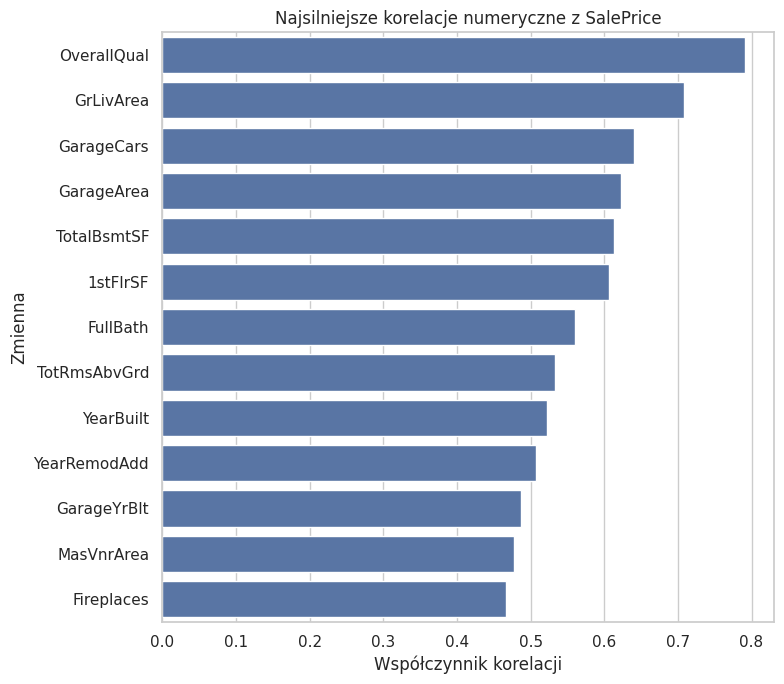

In [689]:
# Wykres silniejszych korelacji z SalePrice
strong_corr_without_target = strong_corr.drop('SalePrice', errors='ignore')

plt.figure(figsize=(8, 7))
sns.barplot(x=strong_corr_without_target.values, y=strong_corr_without_target.index)

plt.title('Najsilniejsze korelacje numeryczne z SalePrice')
plt.xlabel('Współczynnik korelacji')
plt.ylabel('Zmienna')
plt.tight_layout()
plt.show()

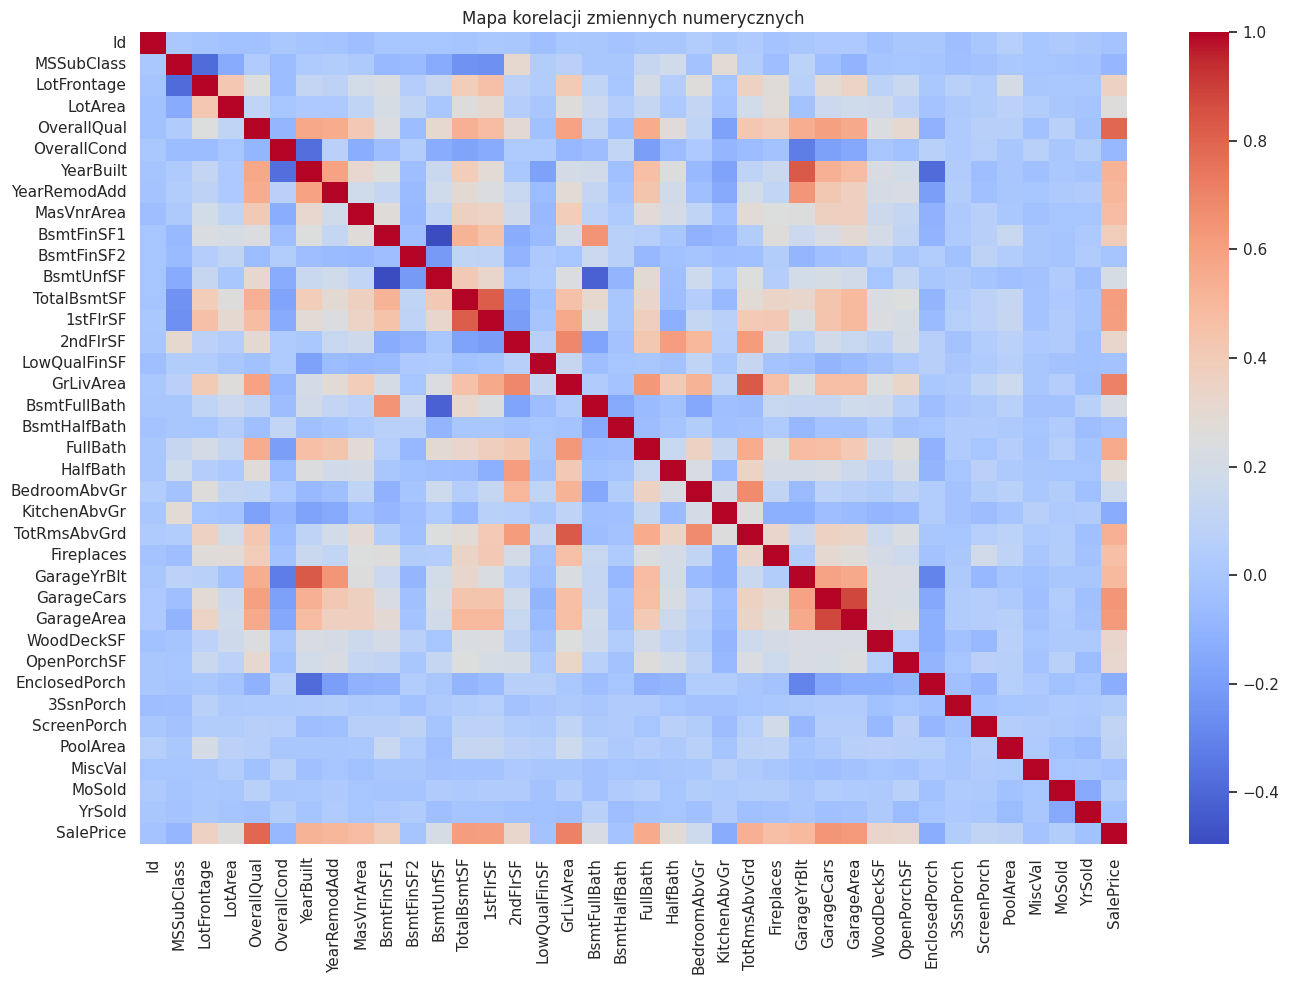

In [690]:
# Heatmapa korelacji dla zmiennych numerycznych
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.select_dtypes(include=['int64', 'float64']).corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Mapa korelacji zmiennych numerycznych')
plt.tight_layout()
plt.show()

## 16. Zależność powierzchni mieszkalnej od ceny

Sprawdzam, czy większa powierzchnia mieszkalna nad poziomem gruntu (`GrLivArea`) wiąże się z wyższą ceną domu.

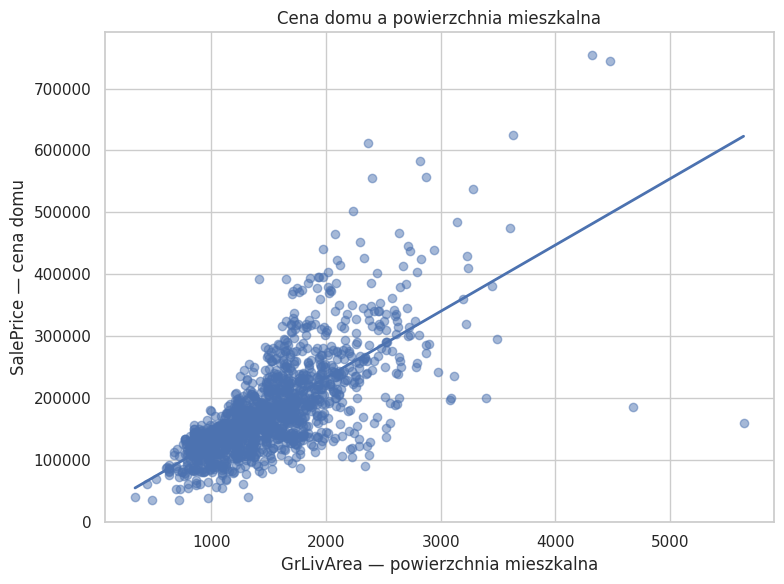

Współczynnik regresji: 107.1303589658252
Wyraz wolny: 18569.02585648722


In [ ]:
# Above Grade Living Area = powierzchnia mieszkalna
# Wykres punktowy z linią regresji
plt.figure(figsize=(8, 6))

sns.regplot(data=df,x='GrLivArea',y='SalePrice',ci=None,scatter_kws={'alpha': 0.5},line_kws={'linewidth': 2})

plt.title("Cena domu a powierzchnia mieszkalna")
plt.xlabel("GrLivArea — powierzchnia mieszkalna")
plt.ylabel("SalePrice — cena domu")
plt.tight_layout()
plt.show()

# Prosty model regresji liniowej tylko dla jednej zmiennej
X_single = df[['GrLivArea']]
y_single = df['SalePrice']

single_model = LinearRegression()
single_model.fit(X_single, y_single)

print("Współczynnik regresji:", single_model.coef_[0])
print("Wyraz wolny:", single_model.intercept_)

## 17. Metody statystyczne

W tej części wykorzystuję metody statystyczne, aby lepiej odpowiedzieć na pytania badawcze:
- korelację Pearsona,
- korelację Spearmana

In [692]:
# Korelacja Pearsona i Spearmana dla GrLivArea i SalePrice
# Pearson bada zależność liniową, a Spearman monotoniczną.
pearson_corr, pearson_p = pearsonr(df['GrLivArea'], df['SalePrice'])
spearman_corr, spearman_p = spearmanr(df['GrLivArea'], df['SalePrice'])

print(f"Pearson correlation: {pearson_corr:.4f}, p-value: {pearson_p:.4e}")
print(f"Spearman correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}")

Pearson correlation: 0.7086, p-value: 4.5180e-223
Spearman correlation: 0.7313, p-value: 1.4310e-244


## 18. Przygotowanie danych do modelowania

Przed trenowaniem modelu:
- usuwam `SalePrice` z cech, ponieważ jest to zmienna docelowa,
- usuwam `Id`, ponieważ jest identyfikatorem, a nie cechą opisującą dom,
- pozostałe zmienne kategoryczne koduję przez `get_dummies`.

In [694]:
# Przygotowanie X i y
X = df1.drop(columns=['SalePrice', 'Id'])
y = df1['SalePrice']

# Kontrola, czy zostały jeszcze jakieś kolumny tekstowe
print("Kolumny tekstowe przed końcowym get_dummies:")
display(X.select_dtypes(include='object').columns)

# Końcowe kodowanie pozostałych zmiennych kategorycznych
X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Rozmiar macierzy cech po kodowaniu:", X.shape)

Kolumny tekstowe przed końcowym get_dummies:


Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'Foundation', 'Heating', 'CentralAir', 'Functional',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

Rozmiar macierzy cech po kodowaniu: (1460, 215)


In [695]:
# Podgląd nazw kolumn po przetworzeniu
cols = X.columns.tolist()
for i in range(0, len(cols), 10):
    print(cols[i : i + 10])

['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'ExterCond']
['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'HeatingQC']
['1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr']
['KitchenQual', 'TotRmsAbvGrd', 'Fireplaces', 'FireplaceQu', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond']
['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC', 'MiscVal', 'MoSold', 'YrSold']
['MiscFeature_None', 'MiscFeature_Othr', 'MiscFeature_Shed', 'MiscFeature_TenC', 'Alley_None', 'Alley_Pave', 'Fence_GdWo', 'Fence_MnPrv', 'Fence_MnWw', 'Fence_None']
['MasVnrType_BrkFace', 'MasVnrType_None', 'MasVnrType_Stone', 'GarageType_Attchd', 'GarageType_Basment', 'GarageType_BuiltIn', 'Garage

## 19. Model bazowy — regresja liniowa

Pierwszym modelem jest regresja liniowa. Używam pipeline, który najpierw standaryzuje dane, a następnie trenuje model.

In [696]:
# Podział danych na zbiór treningowy i walidacyjny
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline: standaryzacja + regresja liniowa
pipeline = Pipeline([('scaler', StandardScaler()),('model', LinearRegression())])

# Trenowanie modelu
pipeline.fit(X_train, y_train)

# Predykcja na zbiorze walidacyjnym
y_pred = pipeline.predict(X_test)

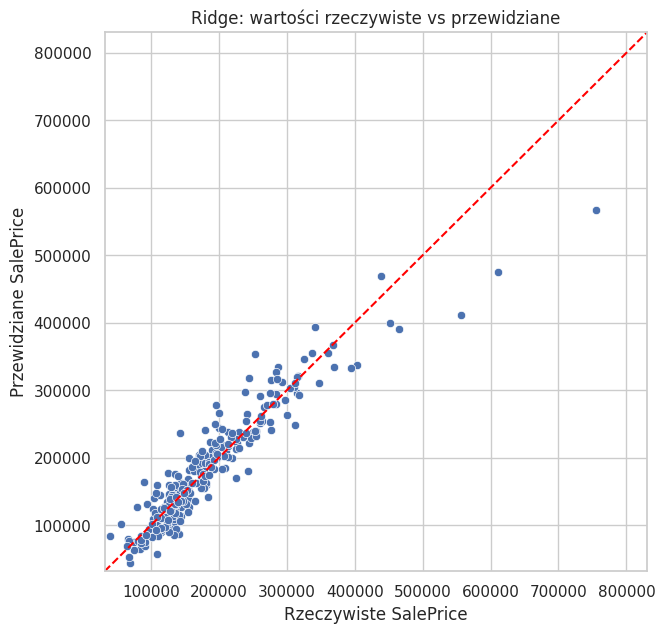

In [697]:
plt.figure(figsize=(7, 7))

sns.scatterplot(x=y_test, y=y_pred)

# Wyznaczenie dolnej i górnej granicy osi, dlaczego ?
lower = y_test.min() * 0.9
upper = y_test.max() * 1.1

plt.plot([lower, upper], [lower, upper], linestyle='--', color='red')

plt.xlim(lower, upper)
plt.ylim(lower, upper)

plt.title('Ridge: wartości rzeczywiste vs przewidziane')
plt.xlabel('Rzeczywiste SalePrice')
plt.ylabel('Przewidziane SalePrice')
plt.show()

## 21. Podsumowanie projektu

W projekcie wykonano:

- wczytanie danych treningowych i testowych,
- analizę braków danych,
- wizualizacje rozkładu ceny i zależności między cechami a ceną,
- kodowanie zmiennych kategorycznych,
- uzupełnianie braków danych,
- analizę korelacji,
- użycie metod statystycznych: Pearson, Spearman,
- zbudowanie modelu regresji liniowej,

Najważniejsze cechy wpływające na cenę domu to zwykle jakość nieruchomości, powierzchnia mieszkalna, garaż, piwnica oraz lokalizacja.

## 1. Cel projektu


W projekcie analizuję dane klientów banku oraz wynik kontaktu telefonicznego. Zmienna docelowa to `response`, czyli informacja, czy klient zgodził się na ofertę lokaty (`yes` / `no`).


### Pytania badawcze

1. Które grupy wiekowe częściej akceptują ofertę?
2. Czy długość rozmowy wpływa na wynik kontaktu?
3. W których miesiącach kampania była najbardziej skuteczna?


## 2. Czyszczenie danych


W tej części przygotowuję dane do dalszej analizy: sprawdzam wartości problematyczne, usuwam wybrane obserwacje odstające i tworzę dodatkowe kolumny pomocnicze.


### 2.1 Wczytanie danych


Dane pochodzą z kampanii telefonicznej banku. Każdy wiersz oznacza jednego klienta, a kolumny opisują m.in. wiek, zawód, saldo, liczbę kontaktów oraz wynik kampanii.


In [698]:
# age       = wiek klienta
# job       = zawód
# marital   = stan cywilny
# education = wykształcenie
# balance   = saldo na koncie
# housing   = czy ma kredyt mieszkaniowy
# loan      = czy ma pożyczkę
# duration  = długość rozmowy
# campaign  = ile razy kontaktowano się z klientem
# poutcome  = wynik poprzedniej kampanii
# response/y = czy klient zgodził się na lokatę: yes/no

In [699]:
# Import podstawowych bibliotek używanych w analizie
import pandas as pd
import numpy as np
from pandas import read_csv
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

from scipy.stats import zscore

# Wczytanie danych z pliku CSV
linkname = 'bank_raw.csv'
df = pd.read_csv(linkname, sep = ';')


Po wczytaniu danych sprawdzam pierwsze wiersze oraz typy kolumn. Dzięki temu można szybko zobaczyć strukturę zbioru i wykryć ewentualne problemy.


In [700]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [701]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### 2.2 Przygotowanie danych


#### Obsługa wartości niejednoznacznych


W danych nie ma klasycznych braków `NaN`, ale występują wartości typu `unknown` i `other`. Traktuję je jako mniej informacyjne i porządkuję je przed analizą.


In [702]:
df["poutcome"].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [703]:
# Usunięcie wierszy, w których poprzedni wynik kampanii ma wartość 'other'
dataset2 = df.drop(df[df.poutcome == 'other'].index, axis = 0, inplace = False)


In [704]:
display(dataset2['job'].unique())
display(dataset2['education'].unique())

array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin.', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object)

In [705]:
# Zamiana wartości 'unknown' w kolumnach job i education na 'other'
dataset2[['job','education']] = dataset2[['job','education']].replace(['unknown'],'other')


#### Usuwanie obserwacji odstających w `balance`


Dla kolumny `balance` sprawdzam wartości odstające metodą z-score. Obserwacje bardzo oddalone od średniej mogłyby zaburzać analizę rozkładu salda.


In [706]:
print("Przed usunięciem outlierów:")
print("Średnia balance:", dataset2['balance'].mean())
print("Odchylenie standardowe balance:", dataset2['balance'].std())

Przed usunięciem outlierów:
Średnia balance: 1356.9630628761154
Odchylenie standardowe balance: 3030.9563483089864


In [707]:
dataset2['balance_outliers'] = dataset2['balance']
dataset2['balance_outliers']= zscore(dataset2['balance_outliers']) #z = (wartość - średnia) / odchylenie standardowe

condition1 = (dataset2['balance_outliers']>3) | (dataset2['balance_outliers']<-3 )
dataset3 = dataset2.drop(dataset2[condition1].index, axis = 0, inplace = False)

In [708]:
print("\nPo usunięciu outlierów:")
print("Średnia balance:", dataset3['balance'].mean())
print("Odchylenie standardowe balance:", dataset3['balance'].std())


Po usunięciu outlierów:
Średnia balance: 1079.8084163638496
Odchylenie standardowe balance: 1717.6237680583386


In [709]:
dataset4 = dataset3.drop('balance_outliers', axis=1)

Text(0.5, 1.0, 'Po usunięciu outlierów')

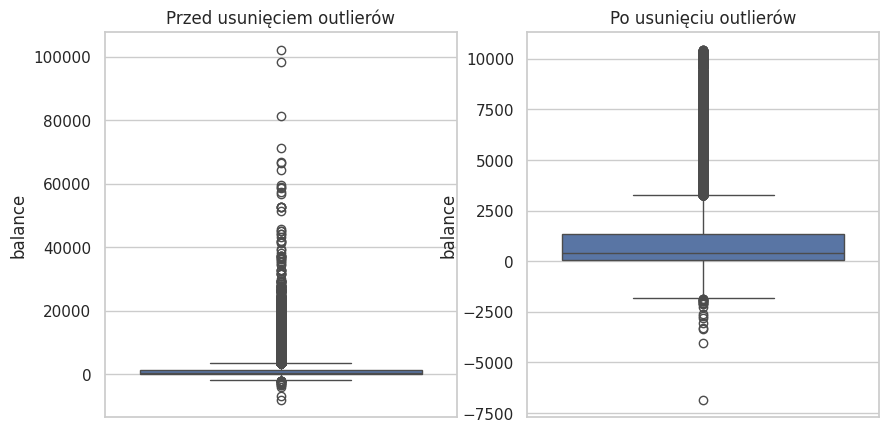

In [710]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=dataset2['balance'])
plt.title("Przed usunięciem outlierów")

plt.subplot(1, 2, 2)
sns.boxplot(y=dataset3['balance'])
plt.title("Po usunięciu outlierów")


#### Tworzenie nowych kolumn


W tym kroku zmieniam nazwę zmiennej docelowej, zamieniam odpowiedź `yes/no` na wartości binarne oraz przeliczam czas rozmowy z sekund na minuty.


In [711]:
# Zmiana nazwy kolumny y na response
dataset4 = dataset4.rename(columns={'y': 'response'})

# Zamiana odpowiedzi yes/no na wartości binarne 1/0
dataset4['response_binary'] = dataset4['response'].map({
    'no': 0,
    'yes': 1
})

# Sprawdzenie liczności klas
dataset4['response_binary'].value_counts()


response_binary
0    37785
1     4870
Name: count, dtype: int64

In [712]:
# Usunięcie kolumny 'contact', ponieważ nie jest używana w dalszej analizie
dataset5 = dataset4.drop('contact', axis=1)

In [713]:
# Przeliczenie czasu rozmowy z sekund na minuty
dataset5['duration'] = dataset5['duration'].apply(lambda n:n/60).round(2)


In [714]:
# Zamiana nazw miesięcy na numery miesięcy
lst = [dataset5]
for column in lst:
    column.loc[column["month"] == "jan", "month_int"] = 1
    column.loc[column["month"] == "feb", "month_int"] = 2
    column.loc[column["month"] == "mar", "month_int"] = 3
    column.loc[column["month"] == "apr", "month_int"] = 4
    column.loc[column["month"] == "may", "month_int"] = 5
    column.loc[column["month"] == "jun", "month_int"] = 6
    column.loc[column["month"] == "jul", "month_int"] = 7
    column.loc[column["month"] == "aug", "month_int"] = 8
    column.loc[column["month"] == "sep", "month_int"] = 9
    column.loc[column["month"] == "oct", "month_int"] = 10
    column.loc[column["month"] == "nov", "month_int"] = 11
    column.loc[column["month"] == "dec", "month_int"] = 12


#### Filtrowanie końcowe


In [715]:
# Usunięcie rozmów krótszych niż 5 sekund
condition2 = (dataset5['duration']<5/60)
dataset6 = dataset5.drop(dataset5[condition2].index, axis = 0, inplace = False)


In [716]:
# Usunięcie klientów z niejednoznaczną kategorią education = 'other'
condition3 = (dataset6['education'] == 'other')
dataset7 = dataset6.drop(dataset6[condition3].index, axis = 0, inplace = False)


## 3. Eksploracyjna analiza danych


W tej części sprawdzam rozkłady najważniejszych zmiennych oraz podstawowe zależności między nimi.


### 3.1 Rozkład wieku i salda


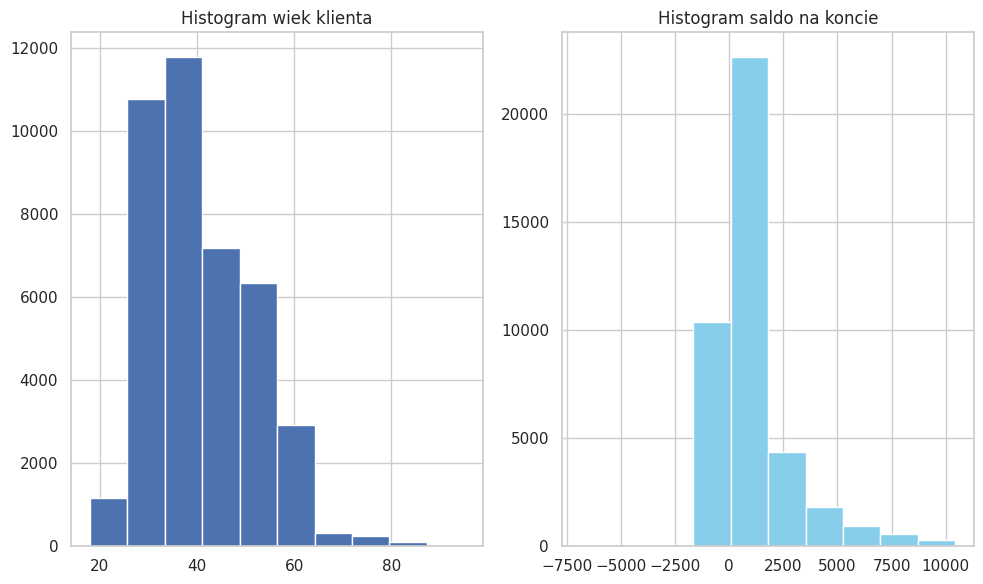

40.79067603633604

1073.9818074973678

In [753]:
dist_age_balance = plt.figure(figsize = (10,6))

ra1 = dist_age_balance.add_subplot(1,2,1) 
ra2 = dist_age_balance.add_subplot(1,2,2)

ra1.hist(dataset7['age'])
ra1.set_title('Histogram wiek klienta')

ra2.hist(dataset7['balance'], color = 'skyblue')
ra2.set_title('Histogram saldo na koncie')

plt.tight_layout() 
plt.show()

display (dataset7['age'].mean())
display (dataset7['balance'].mean())

Większość klientów znajduje się w średnich grupach wiekowych. Rozkład salda pokazuje, że większość klientów ma relatywnie niskie lub umiarkowane saldo.


Wykres salda pomaga ocenić, czy po usunięciu skrajnych obserwacji dane są bardziej czytelne i możliwe do dalszej analizy.


### 3.2 Zależność między wiekiem a saldem


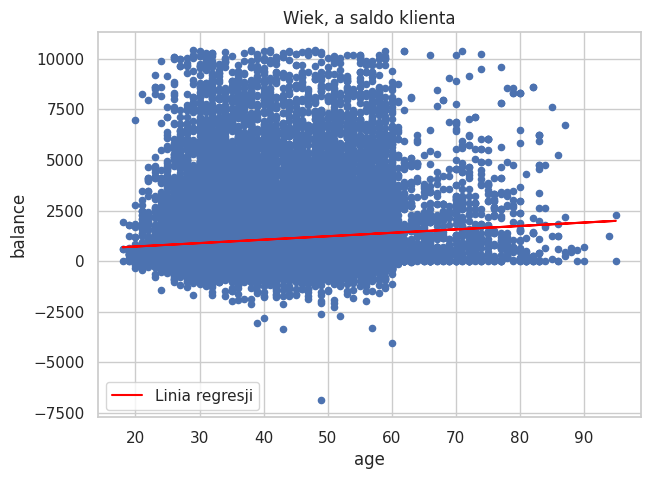

Korelacja Pearsona: 0.103


In [754]:
ax = dataset7.plot.scatter('age', 'balance', figsize=(7,5))

a, b = np.polyfit(dataset7['age'], dataset7['balance'], 1)

x_range = dataset7['age']
plt.plot(x_range, a * x_range + b, color='red', label='Linia regresji')

plt.title('Wiek, a saldo klienta')
plt.legend()
plt.show()

pearson_corr = dataset7['age'].corr(dataset7['balance'], method='pearson')
print(f"Korelacja Pearsona: {pearson_corr:.3f}")

Na wykresie nie widać silnej zależności liniowej między wiekiem klienta a saldem na koncie.


Korelacja Pearsona wynosi 0.103, co oznacza słabą zależność liniową 

### 3.3 Rozkład czasu rozmowy i liczby kontaktów


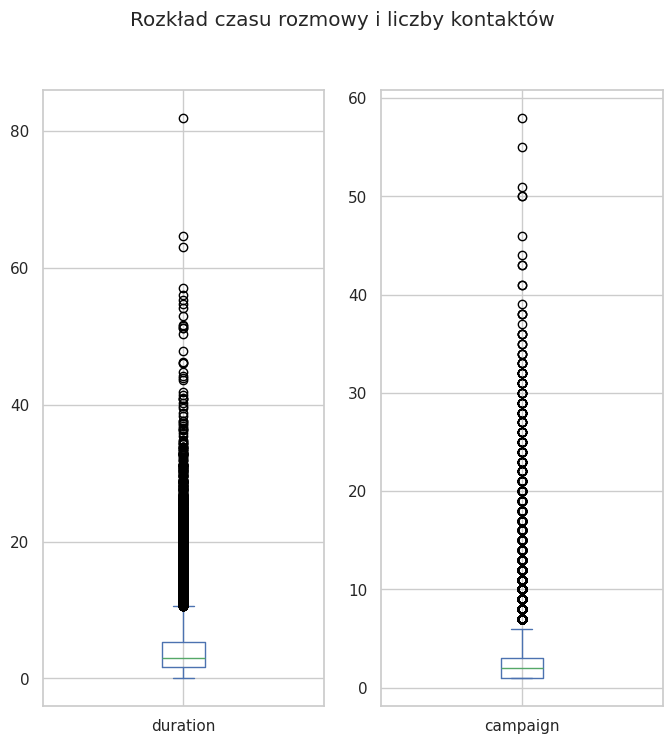

In [719]:
dist_dur_cam = dataset7[['duration','campaign']].plot(kind = 'box', figsize = (8,8),subplots = True, layout = (1,2),title='Rozkład czasu rozmowy i liczby kontaktów')
plt.show()


Wykres pudełkowy pokazuje, że większość rozmów trwa krótko, ale występują też dłuższe rozmowy. Takie wartości mogą mieć znaczenie dla wyniku kampanii.


Zmienna `campaign` pokazuje, ile razy kontaktowano się z klientem w ramach kampanii. Duża liczba kontaktów może oznaczać mniejszą skuteczność lub trudniejszego klienta.


### 3.4 Czas rozmowy i liczba kontaktów a wynik kampanii


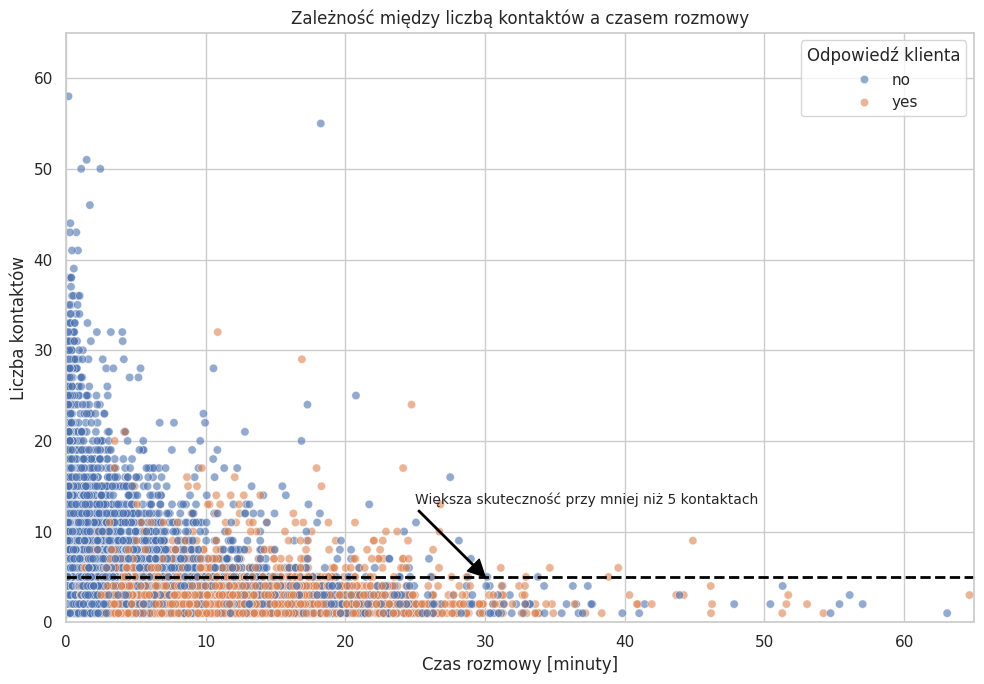

In [720]:
plt.figure(figsize=(10, 7))

# Wykres punktowy: czas rozmowy vs liczba kontaktów
sns.scatterplot(data=dataset7,x='duration',y='campaign',hue='response',alpha=0.6)

# Ograniczenie zakresu osi, żeby wykres był czytelny
plt.xlim(0, 65)
plt.ylim(0, 65)

# Linia pomocnicza pokazująca granicę 5 kontaktów
plt.axhline(y=5,linewidth=2,color='black',linestyle='--')

# Opis linii pomocniczej
plt.annotate('Większa skuteczność przy mniej niż 5 kontaktach',xy=(30, 5),xytext=(25, 13),arrowprops=dict(color='black', width=1),fontsize=10)

# Opisy wykresu
plt.title('Zależność między liczbą kontaktów a czasem rozmowy')
plt.xlabel('Czas rozmowy [minuty]')
plt.ylabel('Liczba kontaktów')
plt.legend(title='Odpowiedź klienta')
plt.tight_layout()
plt.show()

# Cel wykresu:
# Sprawdzamy, czy liczba kontaktów z klientem oraz czas rozmowy mają związek z odpowiedzią klienta.
# Oś X pokazuje czas rozmowy w minutach.
# Oś Y pokazuje liczbę kontaktów wykonanych w ramach kampanii.
# Kolor punktu pokazuje, czy klient odpowiedział pozytywnie czy negatywnie.
# Linia pozioma na poziomie 5 kontaktów pomaga sprawdzić, czy większa liczba kontaktów poprawia skuteczność kampanii.

Kolor punktów pokazuje, czy klient zaakceptował ofertę. Dzięki temu można sprawdzić, czy klienci z dłuższymi rozmowami częściej odpowiadali pozytywnie.


### 3.5 Macierz korelacji


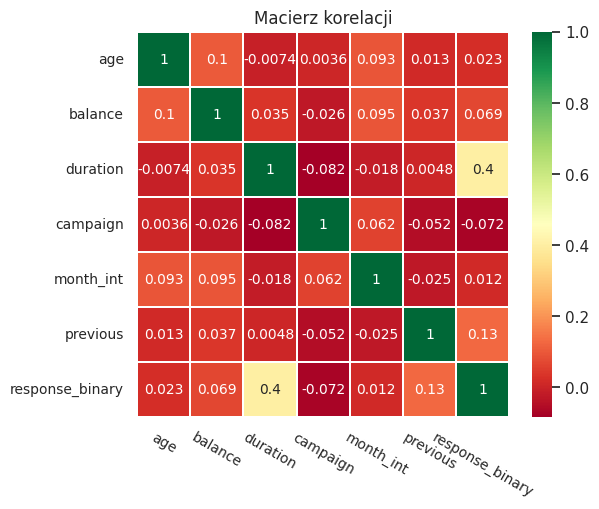

In [721]:
corr_data = dataset7[['age','balance','duration','campaign','month_int','previous','response_binary']]
corr = corr_data.corr()

cor_plot = sns.heatmap(corr,annot=True,cmap='RdYlGn',linewidths=0.2,annot_kws={'size':10})
fig=plt.gcf()
fig.set_size_inches(6,5)
plt.xticks(fontsize=10,rotation=-30)
plt.yticks(fontsize=10)
plt.title('Macierz korelacji')
plt.show()


Macierz korelacji pozwala sprawdzić, które zmienne liczbowe są ze sobą powiązane. Największe znaczenie ma zależność zmiennych z `response_binary`.


## 4. Wizualizacja skuteczności kampanii


W tej części porównuję odsetek klientów, którzy zaakceptowali ofertę, w różnych grupach.


### 4.1 Skuteczność kampanii według wieku


In [722]:
dataset7['age_group'] = pd.cut(dataset7['age'],bins=[0, 29, 39, 49, 59, 100],labels=['<30', '30-39', '40-49', '50-59', '60+'])

In [723]:
age_stats = dataset7.groupby('age_group').agg(liczba_osob=('age', 'count'),subscription_rate=('response', lambda x: (x == 'yes').mean() * 100)).reset_index()

display(age_stats)

#ile osob w danej grupie
#Procent osób, które odpowiedziały yes w danej grupie wiekowej.

,age_group,liczba_osob,subscription_rate
0,<30,4745,16.986301
1,30-39,16566,10.364602
2,40-49,10528,8.824088
3,50-59,7514,9.182859
4,60+,1488,33.400538


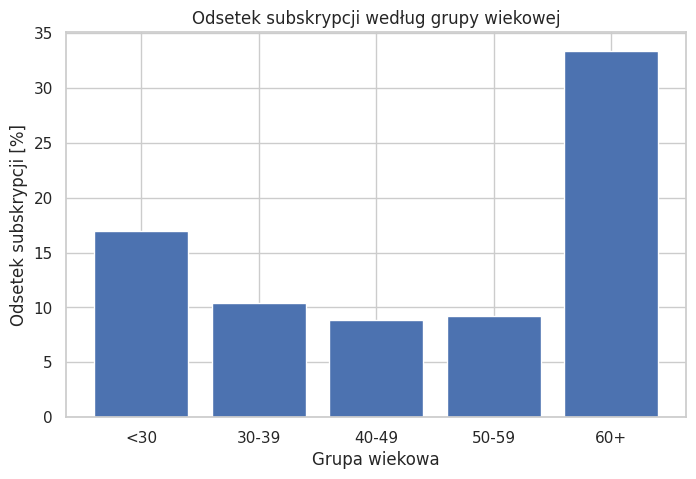

In [724]:
plt.figure(figsize=(8, 5))

plt.bar(age_stats['age_group'], age_stats['subscription_rate'])

plt.title('Odsetek subskrypcji według grupy wiekowej')
plt.xlabel('Grupa wiekowa')
plt.ylabel('Odsetek subskrypcji [%]')

plt.show()


Wniosek: najmłodsze i najstarsze grupy klientów mogą mieć wyższy odsetek pozytywnych odpowiedzi niż część grup w średnim wieku.


### 4.2 Skuteczność kampanii według miesiąca


In [725]:
month_stats = dataset7.groupby('month_int').agg(contacted_count=('response', 'count'),subscription_rate=('response', lambda x: (x == 'yes').mean() * 100)).reset_index()

month_stats['contacted_rate'] = (month_stats['contacted_count'] / month_stats['contacted_count'].sum() * 100)

display(month_stats)

,month_int,contacted_count,subscription_rate,contacted_rate
0,1.0,1183,10.312764,2.896599
1,2.0,2258,17.271922,5.528758
2,3.0,407,54.299754,0.996548
3,4.0,2529,19.612495,6.192307
4,5.0,12496,6.610115,30.596704
5,6.0,4853,10.096847,11.882667
6,7.0,6520,8.466258,15.964350
7,8.0,5877,10.447507,14.389951
8,9.0,457,48.796499,1.118974
9,10.0,605,44.958678,1.481355


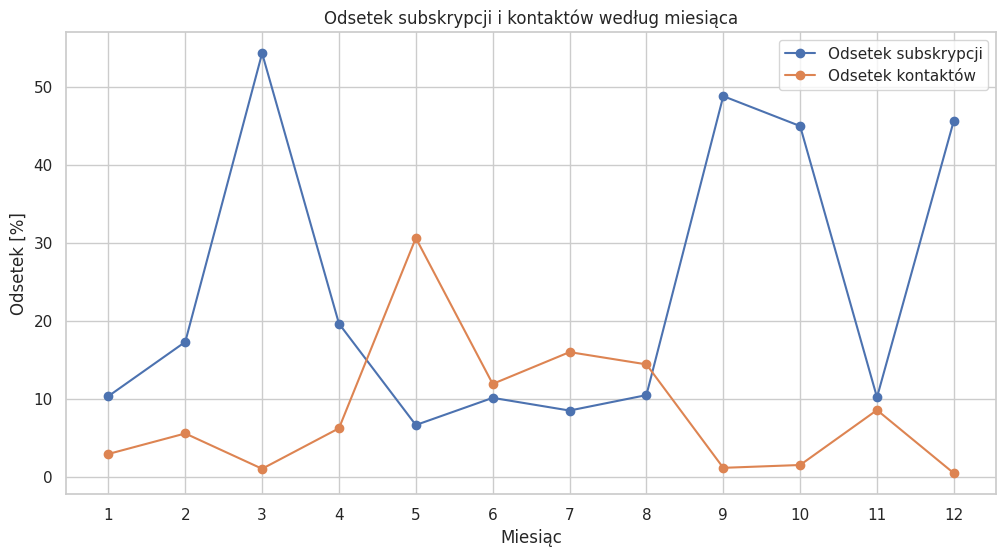

In [726]:
plt.figure(figsize=(12, 6))

plt.plot(month_stats['month_int'], month_stats['subscription_rate'], marker='o', label='Odsetek subskrypcji')
plt.plot(month_stats['month_int'], month_stats['contacted_rate'], marker='o', label='Odsetek kontaktów')

max_sub = month_stats.loc[month_stats['subscription_rate'].idxmax()]
max_con = month_stats.loc[month_stats['contacted_rate'].idxmax()]

plt.title('Odsetek subskrypcji i kontaktów według miesiąca')
plt.xlabel('Miesiąc')
plt.ylabel('Odsetek [%]')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)

plt.show()


### Wnioski z wykresu

Na wykresie porównano odsetek subskrypcji oraz odsetek kontaktów w poszczególnych miesiącach.

Najwyższy odsetek subskrypcji występuje w miesiącach **3, 9, 10 i 12**. Oznacza to, że w tych miesiącach kampania była najbardziej skuteczna pod względem pozytywnych odpowiedzi klientów.

Największy odsetek kontaktów występuje natomiast w miesiącu **5**, jednak nie przekłada się to na najwyższy odsetek subskrypcji. Widać więc, że większa liczba kontaktów nie zawsze oznacza większą skuteczność kampanii.

Przykładowo w miesiącu **3** odsetek subskrypcji jest najwyższy, mimo że odsetek kontaktów jest niski. Może to oznaczać, że ważniejsza od samej liczby kontaktów jest jakość kontaktu, moment przeprowadzenia kampanii albo charakterystyka klientów kontaktowanych w danym miesiącu.

Wniosek ogólny: skuteczność kampanii nie zależy wyłącznie od liczby wykonanych kontaktów. 

## 5. Podsumowanie

Analiza pokazuje, że skuteczność kampanii zależy od cech klienta, m.in. wieku. Takie informacje mogą pomóc bankowi lepiej dobierać grupę docelową i zwiększać efektywność kolejnych kampanii.


## Pytania badawcze

1. Jakie gatunki występują najczęściej w zbiorze Netflix Originals?
2. Jakie języki dominują wśród produkcji Netflix Originals?
3. Jak wygląda rozkład czasu trwania produkcji?
4. Jak wygląda rozkład ocen IMDb i czy występują produkcje skrajnie wysoko lub nisko oceniane?
5. Które gatunki oraz filmy mają najwyższe średnie oceny IMDb?


## 1. Import bibliotek i wczytanie danych

W tej części importujemy biblioteki potrzebne do analizy danych, wizualizacji oraz metod statystycznych. Następnie wczytujemy plik `NetflixOriginals.csv`.


In [727]:
# Biblioteki do pracy z danymi
import numpy as np
import pandas as pd

# Biblioteki do wizualizacji
import matplotlib.pyplot as plt
import seaborn as sns

# Metody statystyczne
from scipy.stats import pearsonr, f_oneway

# Ustawienie stylu wykresów
sns.set_theme(style="whitegrid")

# Wczytanie danych z pliku CSV
# Plik powinien znajdować się w tym samym folderze co notebook.
data = pd.read_csv("NetflixOriginals.csv", encoding='latin-1')


In [728]:
# Podgląd pierwszych wierszy danych
display(data.head())


,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi


In [729]:
# Informacje o liczbie wierszy, kolumnach, typach danych i brakach
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Title       584 non-null    object 
 1   Genre       584 non-null    object 
 2   Premiere    584 non-null    object 
 3   Runtime     584 non-null    int64  
 4   IMDB Score  584 non-null    float64
 5   Language    584 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 27.5+ KB


In [730]:
# Podstawowe statystyki dla kolumn liczbowych
display(data.describe())


,Runtime,IMDB Score
count,584.000000,584.000000
mean,93.577055,6.271747
std,27.761683,0.979256
min,4.000000,2.500000
25%,86.000000,5.700000
50%,97.000000,6.350000
75%,108.000000,7.000000
max,209.000000,9.000000


In [731]:
# Lista kolumn w zbiorze danych
print(data.columns.tolist())


['Title', 'Genre', 'Premiere', 'Runtime', 'IMDB Score', 'Language']


## 2. Sprawdzenie braków danych i przygotowanie daty

Najpierw sprawdzamy, czy w danych występują braki. Następnie kolumna `Premiere` jest zamieniana na typ daty, aby można było analizować rok, miesiąc oraz dzień premiery.


In [732]:
# Liczba braków danych w każdej kolumnie
missing_values = data.isnull().sum()
display(missing_values[missing_values > 0])


Series([], dtype: int64)

In [733]:
# Wyświetlenie tylko tych kolumn, w których występują braki
display(missing_values[missing_values > 0])

# cel -> "October 16. 2019" zamiast "October 16, 2019".

# Regex r"\.\s+(?=\d{4})" oznacza:
# \.        - znajdź kropkę,
# \s+       - po kropce musi być jedna lub więcej spacji,
# (?=\d{4}) - dalej musi występować rok zapisany jako 4 cyfry.

# Rezultat - > Dzięki temu zamieniana jest tylko kropka znajdująca się przed rokiem, a nie każda kropka w tekście.

data["Premiere_clean"] = (data["Premiere"].astype(str).str.replace(r"\.\s+(?=\d{4})", ", ", regex=True))


# Zamiana tekstu z datą na prawdziwy typ datetime.
# errors="coerce" powoduje, że błędnie zapisane daty zostaną zamienione na NaT, zamiast przerywać działanie notebooka.
data["date"] = pd.to_datetime(data["Premiere_clean"], errors="coerce")

Series([], dtype: int64)

In [734]:
# Utworzenie nowych kolumn czasowych do dalszej analizy
data['year_month'] = data['date'].dt.strftime('%Y-%m')
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.dayofweek

# Podgląd danych po dodaniu kolumn czasowych
display(data.head(15))


,Title,Genre,Premiere,Runtime,IMDB Score,Language,Premiere_clean,date,year_month,year,month,day
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese,"August 5, 2019",2019-08-05,2019-08,2019,8,0
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish,"August 21, 2020",2020-08-21,2020-08,2020,8,4
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian,"December 26, 2019",2019-12-26,2019-12,2019,12,3
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English,"January 19, 2018",2018-01-19,2018-01,2018,1,4
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi,"October 30, 2020",2020-10-30,2020-10,2020,10,4
5,Drive,Action,"November 1, 2019",147,3.5,Hindi,"November 1, 2019",2019-11-01,2019-11,2019,11,4
6,Leyla Everlasting,Comedy,"December 4, 2020",112,3.7,Turkish,"December 4, 2020",2020-12-04,2020-12,2020,12,4
7,The Last Days of American Crime,Heist film/Thriller,"June 5, 2020",149,3.7,English,"June 5, 2020",2020-06-05,2020-06,2020,6,4
8,Paradox,Musical/Western/Fantasy,"March 23, 2018",73,3.9,English,"March 23, 2018",2018-03-23,2018-03,2018,3,4
9,Sardar Ka Grandson,Comedy,"May 18, 2021",139,4.1,Hindi,"May 18, 2021",2021-05-18,2021-05,2021,5,1


### Wnioski

Kolumna `Premiere` została poprawnie przekonwertowana na typ daty `datetime`, ponieważ po konwersji nie pojawiły się błędnie odczytane daty.

Na podstawie kolumny `date` utworzono dodatkowe zmienne czasowe: `year_month`, `year`, `month` oraz `day`. Dzięki temu dane można dalej analizować według roku, miesiąca oraz dnia tygodnia premiery.

Dodanie tych kolumn ułatwia późniejszą analizę trendów czasowych, np. sprawdzenie, w których latach lub miesiącach pojawiało się najwięcej produkcji Netflix Originals.

## 3. Analiza gatunków i języków

W tej części sprawdzamy, jakie gatunki oraz języki pojawiają się najczęściej w zbiorze danych.


In [735]:
# Liczba unikalnych gatunków
gen = data["Genre"].nunique()
print("Liczba unikalnych gatunków:", gen)

# Procentowy udział poszczególnych gatunków
display(data["Genre"].value_counts(normalize=True).head(10) * 100)


Liczba unikalnych gatunków: 115


Genre
Documentary        27.226027
Drama              13.184932
Comedy              8.390411
Romantic comedy     6.678082
Thriller            5.650685
Comedy-drama        2.397260
Crime drama         1.883562
Biopic              1.541096
Horror              1.541096
Action              1.198630
Name: proportion, dtype: float64

Genre
Documentary        159
Drama               77
Comedy              49
Romantic comedy     39
Thriller            33
Comedy-drama        14
Crime drama         11
Biopic               9
Horror               9
Action               7
Name: count, dtype: int64

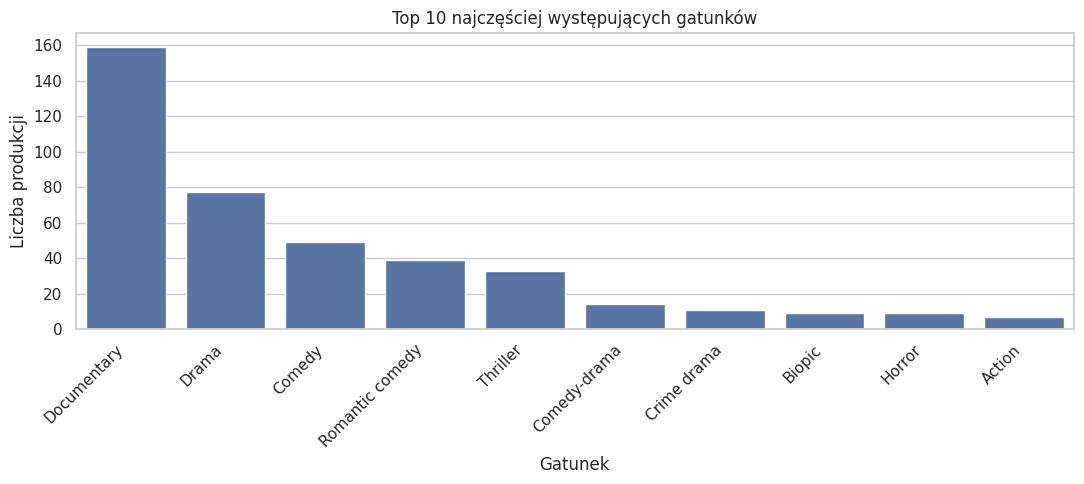

In [736]:
# 10 najczęściej występujących gatunków
genre_top10 = data['Genre'].value_counts().head(10)
display(genre_top10)

plt.figure(figsize=(11, 5))
sns.barplot(x=genre_top10.index, y=genre_top10.values)

plt.title("Top 10 najczęściej występujących gatunków")
plt.xlabel("Gatunek")
plt.ylabel("Liczba produkcji")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Liczba unikalnych języków: 38


Language
English       401
Hindi          33
Spanish        31
French         20
Italian        14
Portuguese     12
Indonesian      9
Japanese        6
Korean          6
German          5
Name: count, dtype: int64

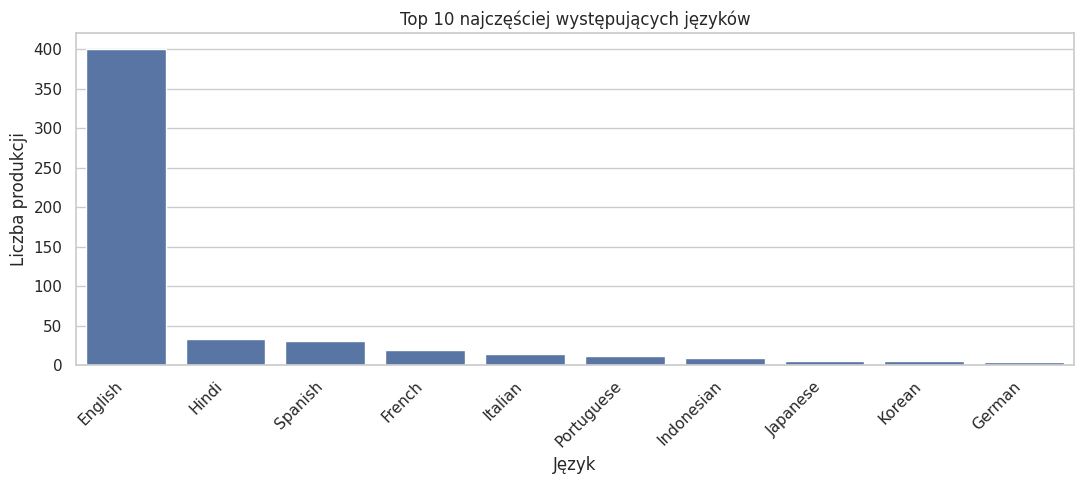

In [737]:
# Liczba unikalnych języków
lang = data['Language'].nunique()
print("Liczba unikalnych języków:", lang)

# 10 najczęściej występujących języków
lang_top10 = data['Language'].value_counts().head(10)
display(lang_top10)

plt.figure(figsize=(11, 5))
sns.barplot(x=lang_top10.index, y=lang_top10.values)

plt.title("Top 10 najczęściej występujących języków")
plt.xlabel("Język")
plt.ylabel("Liczba produkcji")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 4. Analiza czasu trwania produkcji

Sprawdzamy podstawowe statystyki kolumny `Runtime`, a następnie pokazujemy rozkład czasu trwania na histogramie oraz wykresie pudełkowym.


In [738]:
# Statystyki opisowe czasu trwania produkcji
display(data['Runtime'].describe())


count    584.000000
mean      93.577055
std       27.761683
min        4.000000
25%       86.000000
50%       97.000000
75%      108.000000
max      209.000000
Name: Runtime, dtype: float64

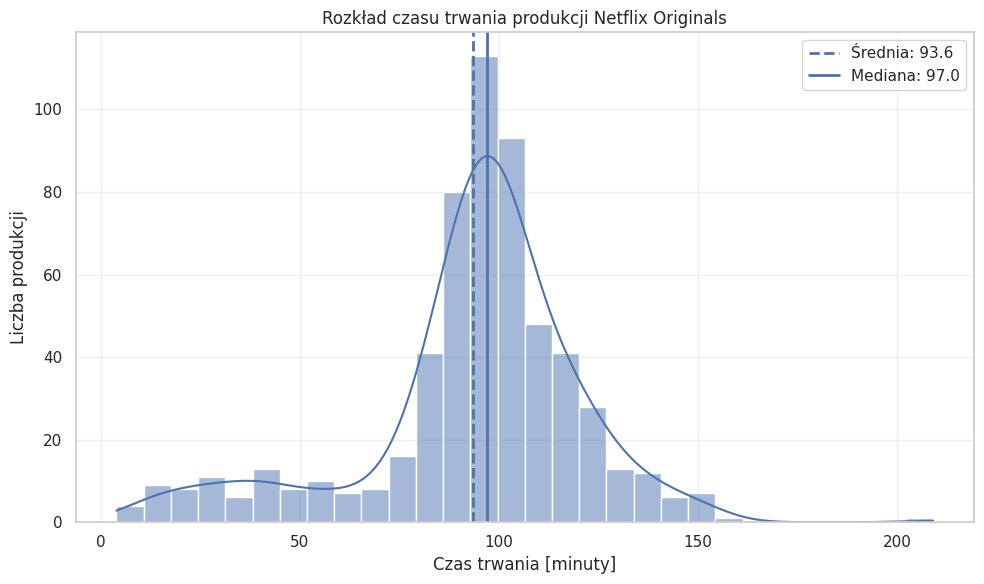

In [739]:
# Średnia i mediana czasu trwania
srednia_runtime = data['Runtime'].mean()
mediana_runtime = data['Runtime'].median()

plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Runtime', bins=30, kde=True)

# Linie pionowe pokazują średnią i medianę
plt.axvline(srednia_runtime, linestyle='--', linewidth=2, label=f'Średnia: {srednia_runtime:.1f}')
plt.axvline(mediana_runtime, linestyle='-', linewidth=2, label=f'Mediana: {mediana_runtime:.1f}')

plt.title('Rozkład czasu trwania produkcji Netflix Originals')
plt.xlabel('Czas trwania [minuty]')
plt.ylabel('Liczba produkcji')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


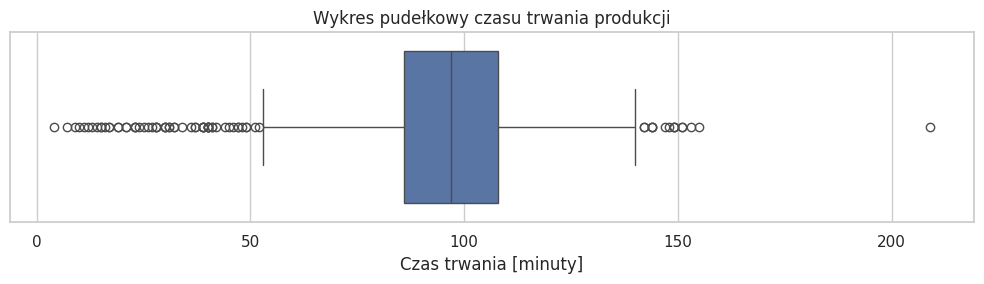

In [740]:
# Wykres pudełkowy pomaga wykryć wartości odstające w czasie trwania produkcji.
plt.figure(figsize=(10, 3))
sns.boxplot(data=data, x='Runtime')

plt.title('Wykres pudełkowy czasu trwania produkcji')
plt.xlabel('Czas trwania [minuty]')
plt.tight_layout()
plt.show()


## 5. Analiza ocen IMDb

W tej części analizujemy rozkład ocen IMDb oraz produkcje o skrajnie wysokich lub niskich ocenach.


In [741]:
# Statystyki opisowe ocen IMDb
display(data["IMDB Score"].describe())


count    584.000000
mean       6.271747
std        0.979256
min        2.500000
25%        5.700000
50%        6.350000
75%        7.000000
max        9.000000
Name: IMDB Score, dtype: float64

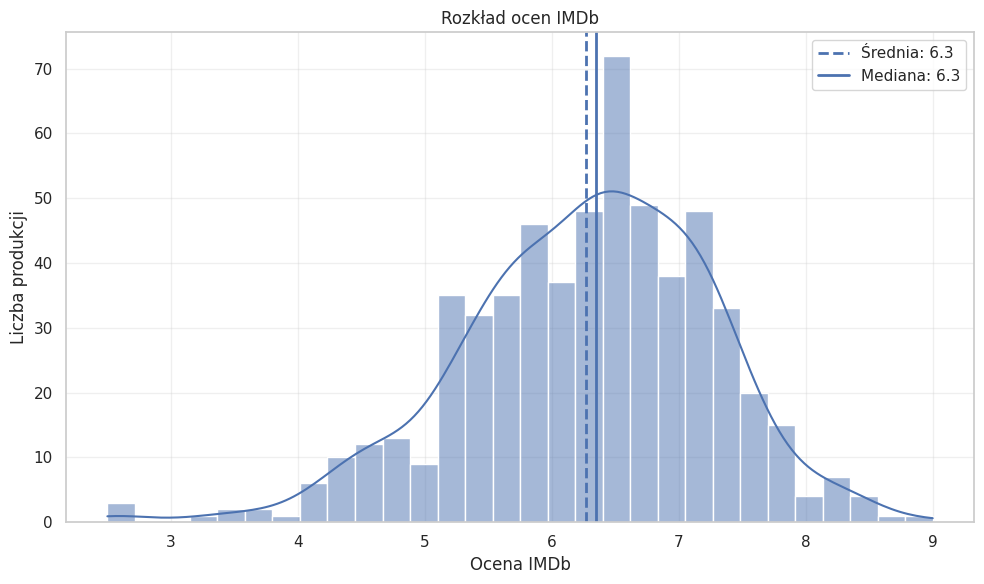

In [742]:
# Średnia i mediana ocen IMDb
srednia_imdb = data['IMDB Score'].mean()
mediana_imdb = data['IMDB Score'].median()

plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='IMDB Score', bins=30, kde=True)

# Linie pionowe pokazują średnią i medianę
plt.axvline(srednia_imdb, linestyle='--', linewidth=2, label=f'Średnia: {srednia_imdb:.1f}')
plt.axvline(mediana_imdb, linestyle='-', linewidth=2, label=f'Mediana: {mediana_imdb:.1f}')

plt.title('Rozkład ocen IMDb')
plt.xlabel('Ocena IMDb')
plt.ylabel('Liczba produkcji')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


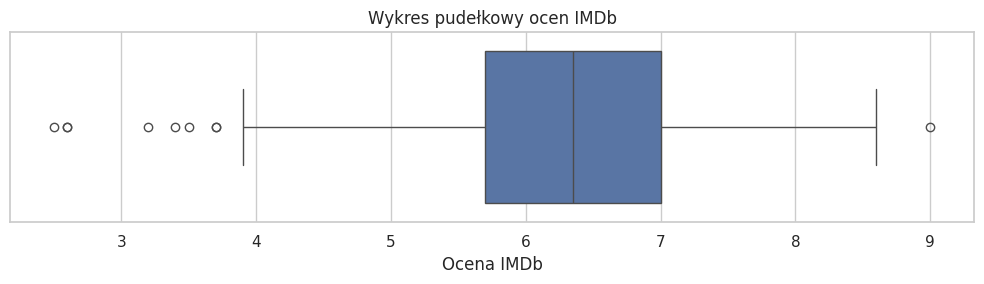

In [743]:
# Wykres pudełkowy ocen IMDb pokazuje medianę, kwartyle oraz potencjalne wartości odstające.
plt.figure(figsize=(10, 3))
sns.boxplot(data=data, x='IMDB Score')

plt.title('Wykres pudełkowy ocen IMDb')
plt.xlabel('Ocena IMDb')
plt.tight_layout()
plt.show()


In [744]:
# Produkcje skrajne: bardzo wysoko ocenione oraz bardzo nisko ocenione.
extreme_scores = data[(data["IMDB Score"] > 8.8) | (data["IMDB Score"] < 4)]
display(extreme_scores[["Title", "Genre", "Language", "Runtime", "IMDB Score"]])


,Title,Genre,Language,Runtime,IMDB Score
0,Enter the Anime,Documentary,English/Japanese,58,2.5
1,Dark Forces,Thriller,Spanish,81,2.6
2,The App,Science fiction/Drama,Italian,79,2.6
3,The Open House,Horror thriller,English,94,3.2
4,Kaali Khuhi,Mystery,Hindi,90,3.4
5,Drive,Action,Hindi,147,3.5
6,Leyla Everlasting,Comedy,Turkish,112,3.7
7,The Last Days of American Crime,Heist film/Thriller,English,149,3.7
8,Paradox,Musical/Western/Fantasy,English,73,3.9
583,David Attenborough: A Life on Our Planet,Documentary,English,83,9.0


## 6. Zależność między czasem trwania a oceną IMDb

Sprawdzamy, czy dłuższe produkcje mają tendencję do uzyskiwania wyższych lub niższych ocen IMDb.


In [745]:
# Macierz korelacji dla czasu trwania i oceny IMDb
runtime_scores_corr = data[['Runtime', 'IMDB Score']].corr()
display(runtime_scores_corr)


,Runtime,IMDB Score
Runtime,1.000000,-0.040896
IMDB Score,-0.040896,1.000000


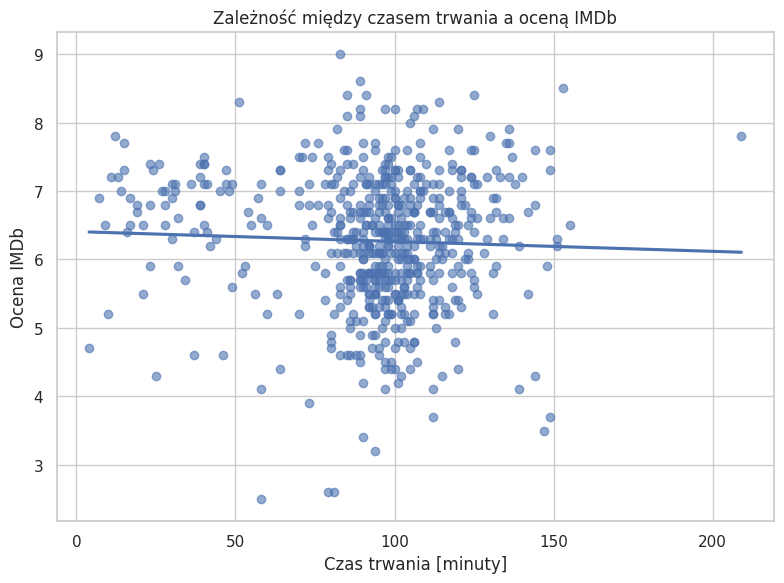

In [746]:
# Wykres punktowy z linią regresji pokazuje zależność między Runtime i IMDB Score.
plt.figure(figsize=(8, 6))
sns.regplot(data=data,x='Runtime',y='IMDB Score',ci=None,scatter_kws={'alpha': 0.6})

plt.title('Zależność między czasem trwania a oceną IMDb')
plt.xlabel('Czas trwania [minuty]')
plt.ylabel('Ocena IMDb')
plt.tight_layout()
plt.show()


## 7. Analiza produkcji w czasie

Sprawdzamy, w których latach pojawiało się najwięcej produkcji Netflix Originals.


year
2014      1
2015      9
2016     30
2017     66
2018     99
2019    125
2020    183
2021     71
Name: count, dtype: int64

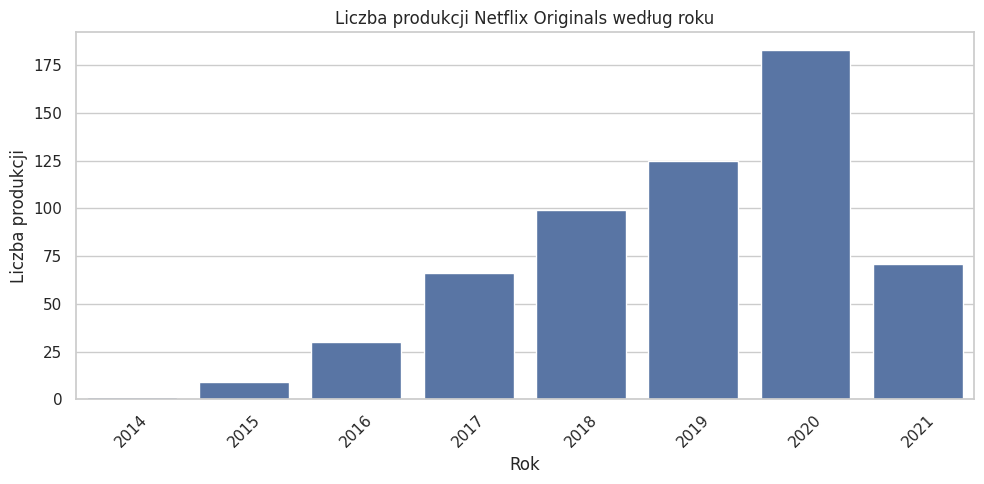

In [747]:
# Liczba produkcji w poszczególnych latach
year = data['year'].value_counts().sort_index()
display(year)

plt.figure(figsize=(10, 5))
sns.barplot(x=year.index.astype(int), y=year.values)

plt.title('Liczba produkcji Netflix Originals według roku')
plt.xlabel('Rok')
plt.ylabel('Liczba produkcji')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Najwyżej oceniane gatunki

Liczymy średnią ocenę IMDb dla każdego gatunku. Warto pamiętać, że wynik może być zawyżony dla gatunków, które mają bardzo mało produkcji.


Genre
Animation/Christmas/Comedy/Adventure    8.200000
Musical / Short                         7.700000
Concert Film                            7.633333
Anthology/Dark comedy                   7.600000
Animation / Science Fiction             7.500000
Making-of                               7.450000
Action-adventure                        7.300000
Historical drama                        7.200000
Coming-of-age comedy-drama              7.200000
Drama-Comedy                            7.200000
Name: IMDB Score, dtype: float64

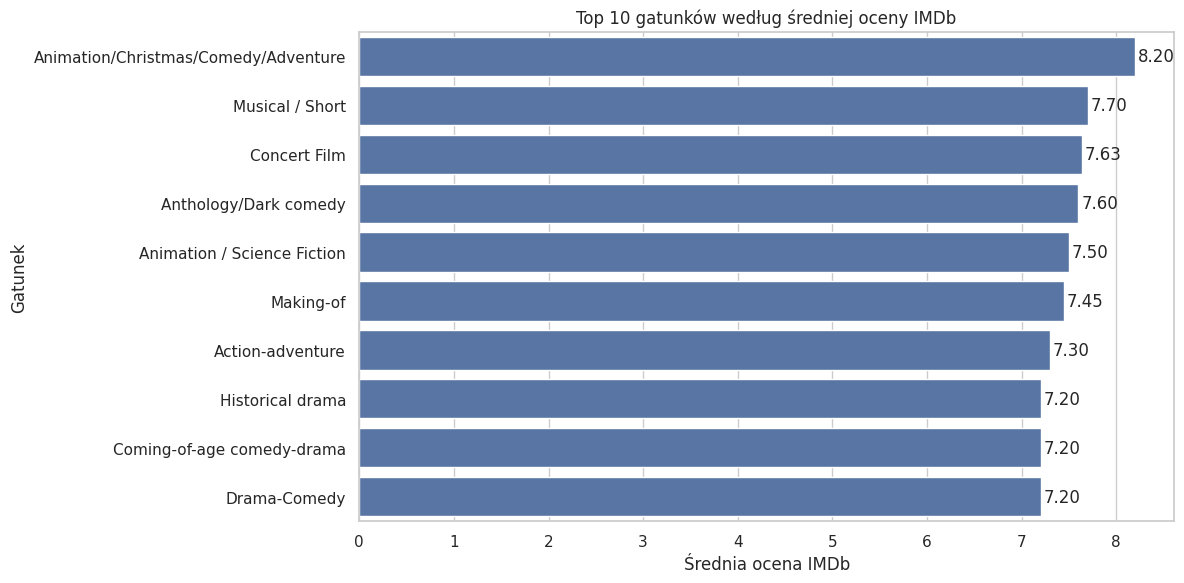

In [748]:
# Top 10 gatunków według średniej oceny IMDb
top_10_rating_bygenre = (data.groupby('Genre')['IMDB Score'].mean().sort_values(ascending=False).head(10))

display(top_10_rating_bygenre)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_10_rating_bygenre.values, y=top_10_rating_bygenre.index)

plt.title('Top 10 gatunków według średniej oceny IMDb')
plt.xlabel('Średnia ocena IMDb')
plt.ylabel('Gatunek')

for i, value in enumerate(top_10_rating_bygenre.values):
    ax.text(value + 0.03, i, f'{value:.2f}', va='center')

plt.tight_layout()
plt.show()


,avg_score,movie_count
Genre,,
Concert Film,7.633333,6
One-man show,7.133333,3
Animation / Short,7.125000,4
Documentary,6.936478,159
Aftershow / Interview,6.750000,6
Crime drama,6.745455,11
Animation,6.560000,5
Romance,6.500000,6
Psychological thriller,6.500000,4


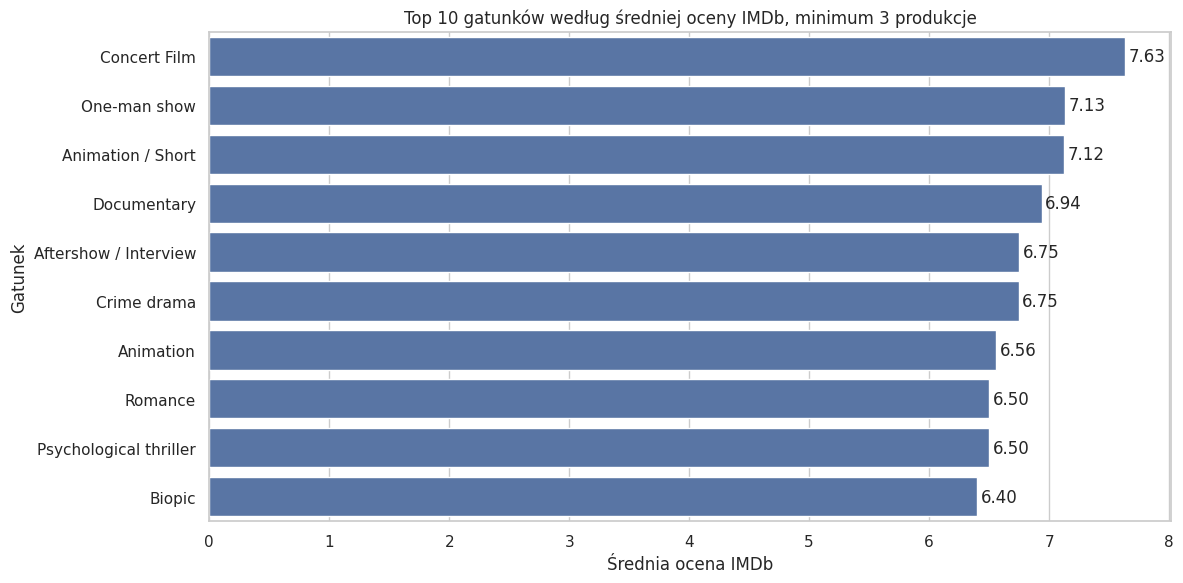

In [749]:
# Bardziej wiarygodna wersja: tylko gatunki z minimum 3 produkcjami.
genre_stats = data.groupby('Genre').agg(avg_score=('IMDB Score', 'mean'),movie_count=('Title', 'count'))

genre_stats = genre_stats[genre_stats['movie_count'] >= 3]
top_10_genres_min3 = genre_stats.sort_values('avg_score', ascending=False).head(10)

display(top_10_genres_min3)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_10_genres_min3, x='avg_score', y=top_10_genres_min3.index)

plt.title('Top 10 gatunków według średniej oceny IMDb, minimum 3 produkcje')
plt.xlabel('Średnia ocena IMDb')
plt.ylabel('Gatunek')

for i, value in enumerate(top_10_genres_min3['avg_score']):
    ax.text(value + 0.03, i, f'{value:.2f}', va='center')

plt.tight_layout()
plt.show()


## 9. Top 20 najwyżej ocenianych produkcji

Na końcu pokazujemy ranking 20 najwyżej ocenianych produkcji w zbiorze danych.


In [750]:
# Wybór 20 najwyżej ocenianych produkcji
top_20_movies = (data[['IMDB Score', 'Title', 'Genre', 'year', 'Language']].sort_values('IMDB Score', ascending=False).head(20))

display(top_20_movies)


,IMDB Score,Title,Genre,year,Language
583,9.0,David Attenborough: A Life on Our Planet,Documentary,2020,English
582,8.6,Emicida: AmarElo - It's All For Yesterday,Documentary,2020,Portuguese
581,8.5,Springsteen on Broadway,One-man show,2018,English
580,8.4,Winter on Fire: Ukraine's Fight for Freedom,Documentary,2015,English/Ukranian/Russian
579,8.4,Taylor Swift: Reputation Stadium Tour,Concert Film,2018,English
578,8.4,Ben Platt: Live from Radio City Music Hall,Concert Film,2020,English
577,8.3,Dancing with the Birds,Documentary,2019,English
576,8.3,Cuba and the Cameraman,Documentary,2017,English
573,8.2,Klaus,Animation/Christmas/Comedy/Adventure,2019,English
571,8.2,13th,Documentary,2016,English


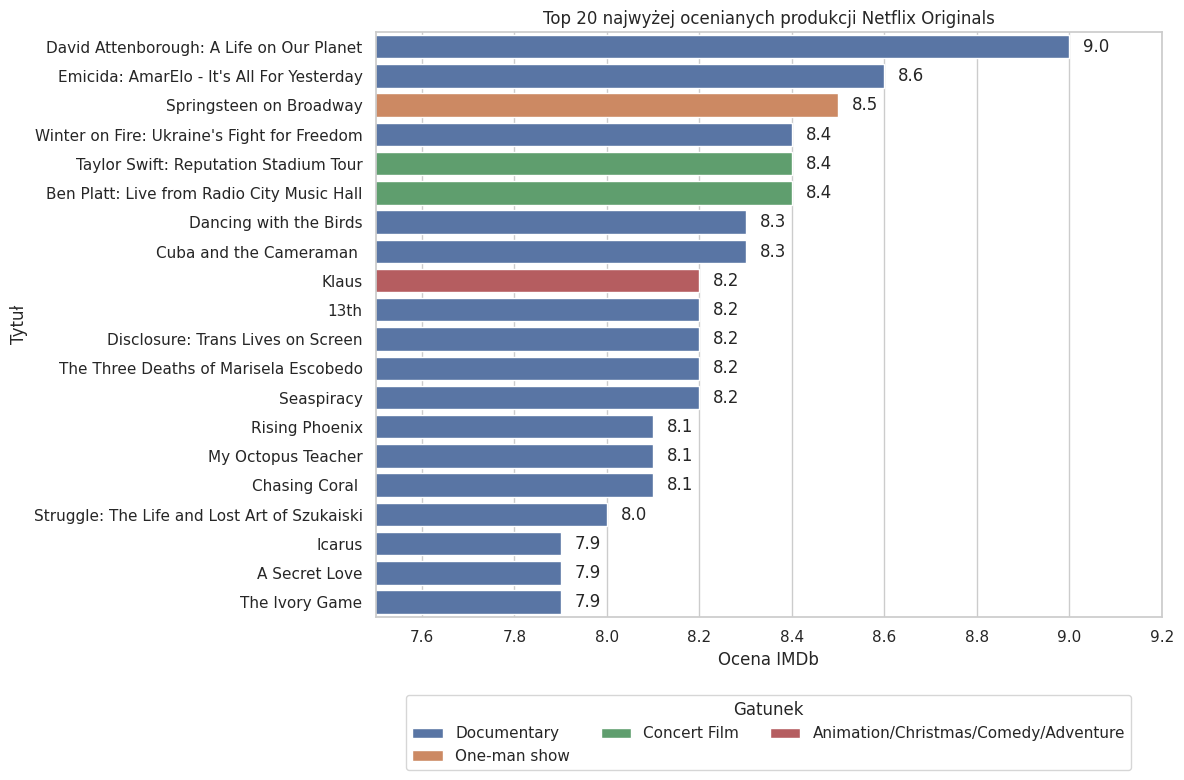

In [751]:
# Poziomy barplot jest czytelniejszy niż scatterplot, ponieważ pokazuje ranking tytułów.
plt.figure(figsize=(12, 8))

ax = sns.barplot(data=top_20_movies,x='IMDB Score',y='Title',hue='Genre',dodge=False)

plt.title('Top 20 najwyżej ocenianych produkcji Netflix Originals')
plt.xlabel('Ocena IMDb')
plt.ylabel('Tytuł')
plt.xlim(7.5, 9.2)

# Podpisanie wartości ocen przy słupkach
for i, value in enumerate(top_20_movies['IMDB Score']):
    ax.text(value + 0.03, i, f'{value:.1f}', va='center')

# Legenda pod wykresem, aby nie zasłaniała danych
plt.legend(title='Gatunek',loc='upper center',bbox_to_anchor=(0.5, -0.12),ncol=3)

plt.tight_layout()
plt.show()


### Wnioski

Wśród najwyżej ocenianych tytułów dominują głównie produkcje dokumentalne i biograficzne, co może sugerować, że tego typu treści są szczególnie wysoko oceniane przez widzów.

Wykres pozwala szybko porównać ranking najlepszych produkcji oraz zauważyć różnice ocen między poszczególnymi tytułami.

## 10. Podsumowanie

Najważniejsze wnioski z analizy:

- Najczęściej występujące gatunki i języki pokazują strukturę katalogu Netflix Originals.
- Histogram czasu trwania pokazuje, że większość produkcji koncentruje się wokół typowej długości filmu.
- Rozkład ocen IMDb pozwala zauważyć, czy oceny są skupione wokół średniej, czy występują skrajne przypadki.
- Korelacja i wykres regresji pomagają sprawdzić, czy czas trwania ma związek z oceną.
- Analiza top gatunków i top filmów pokazuje, które typy produkcji osiągają najwyższe oceny.
